# Project Rooting - Week 2 Ultrasound Pipeline

## Goal

Build an end-to-end controlled B-mode/CEUS ultrasound processing pipeline for TCIA data, including metadata validation, controlled download, DICOM verification, QC automation, frame extraction, dual-panel split validation, pairing candidates, and Week 2 dataset compatibility checks.

## Execution Stages

### Day 1 - Manifest and Controlled Batch Selection
- Retrieve TCIA series manifest
- Validate schema and metadata completeness
- Exclude Week 1 sample
- Select a reproducible resource-aware 10-series batch

### Day 2 - Download, Verification, and Raw Indexing
- Download selected TCIA series
- Verify ZIP integrity
- Extract series
- Run DICOM smoke tests
- Build raw file index and download log

### Day 3 - DICOM Verification and QC
- Parse DICOM headers
- Exclude non-image files
- Build clean DICOM manifest
- Decode representative frames
- Compute QC metrics
- Export preview images

### Day 4 - Dual-Panel Split Validation
- Detect wide dual-panel candidates
- Estimate panel split columns
- Compute split confidence
- Export left/right candidate previews
- Perform manual audit

### Day 5 - Pairing and Validation
- Build validated intra-series pairing candidates
- Export representative frame/panel samples
- Create Week 2 compatibility datalist
- Validate filesystem paths
- Generate final validation report
- Run smoke tests

## Scientific Boundary

This Week 2 pipeline prepares real B-mode/CEUS ultrasound data for future AI, elastography-related extensions, and reconstruction-support experiments. It does not estimate true tissue stiffness, Young's modulus, or biomechanical material parameters from B-mode/CEUS alone.

In [1]:
from pathlib import Path
from typing import Any
from datetime import datetime

import json
import time
import requests
import pandas as pd

In [2]:
PROJECT_ROOT = Path("/kaggle/working/project_rooting_week2")

MANIFEST_DIR = PROJECT_ROOT / "data-manifests"
RAW_DIR = PROJECT_ROOT / "raw"
QC_DIR = PROJECT_ROOT / "qc"
DERIVED_DIR = PROJECT_ROOT / "derived"
EXPORT_DIR = PROJECT_ROOT / "exports"

for directory in [
    MANIFEST_DIR,
    RAW_DIR,
    QC_DIR,
    DERIVED_DIR,
    EXPORT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

COLLECTION = "B-mode-and-CEUS-Liver"

NBIA_BASE = (
    "https://services.cancerimagingarchive.net/"
    "nbia-api/services/v1"
)

print("Project root:", PROJECT_ROOT)
print("Collection:", COLLECTION)
print("Folders created successfully.")

Project root: /kaggle/working/project_rooting_week2
Collection: B-mode-and-CEUS-Liver
Folders created successfully.


In [3]:
def api_get_json(
    endpoint: str,
    params: dict[str, Any] | None = None,
    timeout: int = 120,
    retries: int = 3,
) -> Any:

    if params is None:
        params = {}

    url = f"{NBIA_BASE}/{endpoint}"
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            response = requests.get(
                url,
                params=params,
                timeout=timeout,
            )

            print(
                f"Attempt {attempt} | "
                f"Endpoint: {endpoint} | "
                f"Status: {response.status_code}"
            )

            response.raise_for_status()
            return response.json()

        except Exception as error:
            last_error = error
            print("Request error:", error)

            if attempt < retries:
                time.sleep(2 * attempt)

    raise RuntimeError(
        f"API request failed after {retries} attempts. "
        f"Last error: {last_error}"
    )

In [4]:
collections_data = api_get_json(
    endpoint="getCollectionValues",
    timeout=60,
)

collections_df = pd.DataFrame(collections_data)

print("Number of collections:", len(collections_df))

target_exists = (
    COLLECTION in collections_df["Collection"].values
)

print("Target collection found:", target_exists)

display(
    collections_df[
        collections_df["Collection"] == COLLECTION
    ]
)

Attempt 1 | Endpoint: getCollectionValues | Status: 200
Number of collections: 154
Target collection found: True


,Collection
17,B-mode-and-CEUS-Liver


In [5]:
series_data = api_get_json(
    endpoint="getSeries",
    params={
        "Collection": COLLECTION,
        "format": "json",
    },
    timeout=180,
)

series_df = pd.DataFrame(series_data)

print("Manifest shape:")
print(series_df.shape)

print("\nColumns:")
print(series_df.columns.tolist())

display(series_df.head())

Attempt 1 | Endpoint: getSeries | Status: 200
Manifest shape:
(120, 22)

Columns:
['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDate', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'PatientID', 'Manufacturer', 'ManufacturerModelName', 'SoftwareVersions', 'ImageCount', 'TimeStamp', 'LicenseName', 'LicenseURI', 'CollectionURI', 'FileSize', 'DateReleased', 'StudyDate', 'ThirdPartyAnalysis', 'StudyDesc', 'SeriesDescription']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN


In [6]:
manifest_path = (
    MANIFEST_DIR /
    "tcia_series_manifest_week2.csv"
)

series_df.to_csv(
    manifest_path,
    index=False
)

print("Manifest saved successfully.")
print("Path:", manifest_path)
print("Rows:", len(series_df))
print("Columns:", len(series_df.columns))
print("File exists:", manifest_path.exists())

Manifest saved successfully.
Path: /kaggle/working/project_rooting_week2/data-manifests/tcia_series_manifest_week2.csv
Rows: 120
Columns: 22
File exists: True


In [7]:
required_columns = [
    "SeriesInstanceUID",
    "StudyInstanceUID",
    "PatientID",
    "Collection",
    "Modality",
    "ImageCount",
    "FileSize",
]

missing_required = [
    col for col in required_columns
    if col not in series_df.columns
]

duplicate_series = (
    series_df["SeriesInstanceUID"]
    .duplicated()
    .sum()
)

unique_series = (
    series_df["SeriesInstanceUID"]
    .nunique()
)

unique_studies = (
    series_df["StudyInstanceUID"]
    .nunique()
)

unique_patients = (
    series_df["PatientID"]
    .nunique()
)

print("=== MANIFEST VALIDATION ===")
print("Rows:", len(series_df))
print("Unique series:", unique_series)
print("Unique studies:", unique_studies)
print("Unique patients:", unique_patients)
print("Duplicate SeriesInstanceUID:", duplicate_series)
print("Missing required columns:", missing_required)

=== MANIFEST VALIDATION ===
Rows: 120
Unique series: 120
Unique studies: 120
Unique patients: 120
Duplicate SeriesInstanceUID: 0
Missing required columns: []


In [8]:
series_df["FileSize_GB"] = (
    pd.to_numeric(
        series_df["FileSize"],
        errors="coerce"
    )
    / (1024 ** 3)
)

series_df["ImageCount_num"] = pd.to_numeric(
    series_df["ImageCount"],
    errors="coerce"
)

print("=== COLLECTION SIZE SUMMARY ===")
print("Total size GB:", round(series_df["FileSize_GB"].sum(), 2))
print("Median series size GB:", round(series_df["FileSize_GB"].median(), 2))
print("Minimum series size GB:", round(series_df["FileSize_GB"].min(), 2))
print("Maximum series size GB:", round(series_df["FileSize_GB"].max(), 2))

display(
    series_df[
        [
            "PatientID",
            "ImageCount_num",
            "FileSize_GB",
        ]
    ]
    .sort_values("FileSize_GB")
    .head(15)
)

=== COLLECTION SIZE SUMMARY ===
Total size GB: 253.47
Median series size GB: 1.91
Minimum series size GB: 0.24
Maximum series size GB: 6.18


,PatientID,ImageCount_num,FileSize_GB
117,LiverUS-107,3,0.241863
113,LiverUS-78,12,0.292500
80,LiverUS-84,12,0.301227
77,LiverUS-87,34,0.308661
100,LiverUS-120,6,0.321274
78,LiverUS-85,16,0.365176
116,LiverUS-121,6,0.420533
109,LiverUS-110,8,0.459632
88,LiverUS-116,7,0.481751
95,LiverUS-83,17,0.486006


## 6. Manifest Missing-Values Audit

Check missing metadata fields before controlled batch selection and later B-mode/CEUS pairing logic.

In [9]:
important_columns = [
    "SeriesInstanceUID",
    "StudyInstanceUID",
    "PatientID",
    "Modality",
    "ImageCount",
    "FileSize",
    "SeriesDescription",
    "StudyDesc",
]

available_columns = [
    col
    for col in important_columns
    if col in series_df.columns
]

null_summary = pd.DataFrame({
    "column": available_columns,
    "null_count": [
        int(series_df[col].isna().sum())
        for col in available_columns
    ],
})

null_summary["null_percent"] = (
    null_summary["null_count"]
    / len(series_df)
    * 100
).round(2)

print("=== MISSING VALUES SUMMARY ===")
print(null_summary.to_string(index=False))

=== MISSING VALUES SUMMARY ===
           column  null_count  null_percent
SeriesInstanceUID           0           0.0
 StudyInstanceUID           0           0.0
        PatientID           0           0.0
         Modality           0           0.0
       ImageCount           0           0.0
         FileSize           0           0.0
SeriesDescription         117          97.5
        StudyDesc         108          90.0


## 7. Week 1 Sample Exclusion Check

Search Kaggle inputs for the Week 1 selected-series manifest to avoid reusing previously processed series in the Week 2 controlled batch.

In [11]:
week1_selection_files = list(
    Path("/kaggle/input").rglob(
        "selected_sample_series.csv"
    )
)

print("=== WEEK 1 SELECTION SEARCH ===")

print(
    "Week 1 selection files found:",
    len(week1_selection_files)
)

if week1_selection_files:
    for path in week1_selection_files:
        print("Found:", path)
else:
    print(
        "Week 1 selected_sample_series.csv "
        "was not found in current Kaggle inputs."
    )

=== WEEK 1 SELECTION SEARCH ===
Week 1 selection files found: 1
Found: /kaggle/input/datasets/omneyasaeid/selected-sample-series-csv/selected_sample_series.csv


In [12]:
# Read Week 1 selected series

if len(week1_selection_files) == 0:
    raise FileNotFoundError(
        "Week 1 selected_sample_series.csv is still not available."
    )

week1_selection_path = week1_selection_files[0]

week1_selected_df = pd.read_csv(
    week1_selection_path
)

print("Week 1 selection file:")
print(week1_selection_path)

print("\nWeek 1 rows:")
print(len(week1_selected_df))

print("\nColumns:")
print(week1_selected_df.columns.tolist())

display(week1_selected_df)

Week 1 selection file:
/kaggle/input/datasets/omneyasaeid/selected-sample-series-csv/selected_sample_series.csv

Week 1 rows:
5

Columns:
['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDate', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'PatientID', 'Manufacturer', 'ManufacturerModelName', 'SoftwareVersions', 'ImageCount', 'TimeStamp', 'LicenseName', 'LicenseURI', 'CollectionURI', 'FileSize', 'DateReleased', 'StudyDate', 'ThirdPartyAnalysis', 'StudyDesc', 'SeriesDescription']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,ManufacturerModelName,...,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDate,ThirdPartyAnalysis,StudyDesc,SeriesDescription
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.738581576903...,1.3.6.1.4.1.14519.5.2.1.1188.2803.272546201471...,US,2012-07-13 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-01,GE Healthcare,LOGIQE9,...,2021-07-16 09:04:17.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,627801216,2021-08-04 00:00:00.0,2012-07-13 00:00:00.0,NO,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.115374966380...,1.3.6.1.4.1.14519.5.2.1.1188.2803.470462341477...,US,2013-04-29 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-51,GE Healthcare,LOGIQE9,...,2021-07-16 08:53:00.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,2020753880,2021-08-04 00:00:00.0,2013-04-29 00:00:00.0,NO,NaN,NaN
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.249116980803...,1.3.6.1.4.1.14519.5.2.1.1188.2803.218426755577...,US,2014-02-14 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-37,GE Healthcare,LOGIQE9,...,2021-07-16 08:59:57.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3138739970,2021-08-04 00:00:00.0,2014-02-14 00:00:00.0,NO,NaN,NaN
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.240884965319...,1.3.6.1.4.1.14519.5.2.1.1188.2803.279513797246...,US,2012-08-25 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-04,GE Healthcare,LOGIQE9,...,2021-07-16 09:06:21.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,1651824828,2021-08-04 00:00:00.0,2012-08-25 00:00:00.0,NO,NaN,NaN
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.146087891599...,1.3.6.1.4.1.14519.5.2.1.1188.2803.222440931622...,US,2012-02-17 00:00:00.0,LIVER,1,B-mode-and-CEUS-Liver,LiverUS-22,GE Healthcare,LOGIQE9,...,2021-07-16 09:05:55.0,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,https://doi.org/10.7937/TCIA.2021.v4z7-tc39,3372349942,2021-08-04 00:00:00.0,2012-02-17 00:00:00.0,NO,NaN,NaN


In [13]:
if "SeriesInstanceUID" not in week1_selected_df.columns:
    raise ValueError(
        "SeriesInstanceUID column was not found "
        "in the Week 1 selection file."
    )

week1_series_uids = set(
    week1_selected_df["SeriesInstanceUID"]
    .dropna()
    .astype(str)
)

print(
    "Week 1 series UIDs loaded:",
    len(week1_series_uids)
)

Week 1 series UIDs loaded: 5


In [14]:
candidate_df = series_df.copy()

candidate_df["SeriesInstanceUID"] = (
    candidate_df["SeriesInstanceUID"]
    .astype(str)
)

candidate_df = candidate_df[
    ~candidate_df["SeriesInstanceUID"]
    .isin(week1_series_uids)
].copy()

print("Original series:", len(series_df))
print("Week 1 excluded:", len(week1_series_uids))
print("Remaining candidates:", len(candidate_df))

Original series: 120
Week 1 excluded: 5
Remaining candidates: 115


In [15]:
# Ensure numeric file size column exists

candidate_df["FileSize_GB"] = (
    pd.to_numeric(
        candidate_df["FileSize"],
        errors="coerce"
    )
    / (1024 ** 3)
)

candidate_df["ImageCount_num"] = pd.to_numeric(
    candidate_df["ImageCount"],
    errors="coerce"
)

In [20]:
BATCH_SIZE = 10
SEED = 42

PRIMARY_SIZE_LIMIT_GB = 1.0
FALLBACK_SIZE_LIMIT_GB = 1.2


primary_pool = candidate_df[
    candidate_df["FileSize_GB"]
    <= PRIMARY_SIZE_LIMIT_GB
].copy()

print(
    "Candidates <= 1.0 GB:",
    len(primary_pool)
)


if len(primary_pool) >= BATCH_SIZE:
    selection_pool = primary_pool.copy()
    applied_size_limit = PRIMARY_SIZE_LIMIT_GB

else:
    selection_pool = candidate_df[
        candidate_df["FileSize_GB"]
        <= FALLBACK_SIZE_LIMIT_GB
    ].copy()

    applied_size_limit = FALLBACK_SIZE_LIMIT_GB


print(
    "Final selection pool size:",
    len(selection_pool)
)

print(
    "Applied maximum series size GB:",
    applied_size_limit
)


if len(selection_pool) < BATCH_SIZE:
    raise ValueError(
        "Not enough series in the resource-aware pool."
    )


selected_batch_df = (
    selection_pool
    .sample(
        n=BATCH_SIZE,
        random_state=SEED
    )
    .sort_values(
        "FileSize_GB"
    )
    .reset_index(drop=True)
)


selected_batch_df.insert(
    0,
    "batch_order",
    range(
        1,
        len(selected_batch_df) + 1
    )
)


selected_batch_df["week"] = "week2"


selected_batch_df[
    "selection_reason"
] = (
    "full_week2_resource_aware_batch_"
    "excluding_week1_"
    f"max_{str(applied_size_limit).replace('.', '_')}GB"
)


display(
    selected_batch_df[
        [
            "batch_order",
            "PatientID",
            "ImageCount_num",
            "FileSize_GB",
            "SeriesInstanceUID",
        ]
    ]
)

Candidates <= 1.0 GB: 36
Final selection pool size: 36
Applied maximum series size GB: 1.0


,batch_order,PatientID,ImageCount_num,FileSize_GB,SeriesInstanceUID
0,1,LiverUS-107,3,0.241863,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...
1,2,LiverUS-84,12,0.301227,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...
2,3,LiverUS-110,8,0.459632,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...
3,4,LiverUS-86,22,0.607097,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...
4,5,LiverUS-106,4,0.702241,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...
5,6,LiverUS-118,11,0.746501,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...
6,7,LiverUS-73,10,0.803327,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...
7,8,LiverUS-63,8,0.823069,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...
8,9,LiverUS-76,14,0.953794,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...
9,10,LiverUS-102,7,0.990778,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...


In [21]:
batch_total_gb = (
    selected_batch_df[
        "FileSize_GB"
    ]
    .sum()
)


print("=== FULL WEEK 2 BATCH SUMMARY ===")

print(
    "Selected series:",
    len(selected_batch_df)
)

print(
    "Estimated download size GB:",
    round(batch_total_gb, 2)
)

print(
    "Mean series size GB:",
    round(
        selected_batch_df[
            "FileSize_GB"
        ].mean(),
        2
    )
)

print(
    "Minimum series size GB:",
    round(
        selected_batch_df[
            "FileSize_GB"
        ].min(),
        2
    )
)

print(
    "Maximum series size GB:",
    round(
        selected_batch_df[
            "FileSize_GB"
        ].max(),
        2
    )
)

print(
    "Total ImageCount:",
    int(
        selected_batch_df[
            "ImageCount_num"
        ].sum()
    )
)

=== FULL WEEK 2 BATCH SUMMARY ===
Selected series: 10
Estimated download size GB: 6.63
Mean series size GB: 0.66
Minimum series size GB: 0.24
Maximum series size GB: 0.99
Total ImageCount: 99


In [22]:
selected_batch_path = (
    MANIFEST_DIR
    / "selected_batch_series_week2.csv"
)

selected_batch_df.to_csv(
    selected_batch_path,
    index=False,
)

print("=== WEEK 2 CONTROLLED BATCH SAVED ===")
print("Path:", selected_batch_path)
print("Rows:", len(selected_batch_df))
print(
    "Estimated size GB:",
    round(
        selected_batch_df["FileSize_GB"].sum(),
        2,
    )
)
print("File exists:", selected_batch_path.exists())

=== WEEK 2 CONTROLLED BATCH SAVED ===
Path: /kaggle/working/project_rooting_week2/data-manifests/selected_batch_series_week2.csv
Rows: 10
Estimated size GB: 6.63
File exists: True


## 8. Day 1 Artifact Export

Save the validated manifest report, controlled Week 2 batch, and Day 1 execution summary before starting series download.

In [23]:
manifest_report = {
    "created_at": datetime.now().isoformat(),
    "collection": COLLECTION,

    "manifest_rows": int(len(series_df)),
    "manifest_columns": int(len(series_df.columns)),

    "unique_series": int(unique_series),
    "unique_studies": int(unique_studies),
    "unique_patients": int(unique_patients),

    "duplicate_series_uid_count": int(
        duplicate_series
    ),

    "missing_required_columns": missing_required,

    "important_metadata_missingness": {
        row["column"]: {
            "null_count": int(row["null_count"]),
            "null_percent": float(row["null_percent"]),
        }
        for _, row in null_summary.iterrows()
    },
}


manifest_report_path = (
    MANIFEST_DIR
    / "tcia_series_manifest_week2_report.json"
)


with open(
    manifest_report_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest_report,
        f,
        indent=2,
    )


print(
    json.dumps(
        manifest_report,
        indent=2,
    )
)

print(
    "\nSaved:",
    manifest_report_path,
)

{
  "created_at": "2026-07-04T18:00:39.845089",
  "collection": "B-mode-and-CEUS-Liver",
  "manifest_rows": 120,
  "manifest_columns": 24,
  "unique_series": 120,
  "unique_studies": 120,
  "unique_patients": 120,
  "duplicate_series_uid_count": 0,
  "missing_required_columns": [],
  "important_metadata_missingness": {
    "SeriesInstanceUID": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "StudyInstanceUID": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "PatientID": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "Modality": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "ImageCount": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "FileSize": {
      "null_count": 0,
      "null_percent": 0.0
    },
    "SeriesDescription": {
      "null_count": 117,
      "null_percent": 97.5
    },
    "StudyDesc": {
      "null_count": 108,
      "null_percent": 90.0
    }
  }
}

Saved: /kaggle/working/project_rooting_week2/

In [24]:
day1_summary = {
    "created_at": datetime.now().isoformat(),

    "week": "Week 2",
    "day": "Day 1",

    "collection": COLLECTION,

    "manifest_series": int(
        len(series_df)
    ),

    "week1_series_excluded": int(
        len(week1_series_uids)
    ),

    "remaining_candidates": int(
        len(candidate_df)
    ),

    "selected_series": int(
        len(selected_batch_df)
    ),

    "estimated_download_size_gb": round(
        float(
            selected_batch_df[
                "FileSize_GB"
            ].sum()
        ),
        2,
    ),

    "total_selected_image_count": int(
        selected_batch_df[
            "ImageCount_num"
        ].sum()
    ),

    "selection_seed": SEED,

    "selection_size_limit_gb": float(
        applied_size_limit
    ),

    "outputs": {
        "series_manifest": str(
            manifest_path
        ),
        "manifest_report": str(
            manifest_report_path
        ),
        "selected_batch": str(
            selected_batch_path
        ),
    },

    "next_step": (
        "Day 2: controlled series download, "
        "ZIP verification, extraction, "
        "DICOM smoke testing, and raw indexing."
    ),
}


day1_summary_path = (
    MANIFEST_DIR
    / "week2_day1_summary.json"
)


with open(
    day1_summary_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        day1_summary,
        f,
        indent=2,
    )


print(
    json.dumps(
        day1_summary,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T18:01:12.286938",
  "week": "Week 2",
  "day": "Day 1",
  "collection": "B-mode-and-CEUS-Liver",
  "manifest_series": 120,
  "week1_series_excluded": 5,
  "remaining_candidates": 115,
  "selected_series": 10,
  "estimated_download_size_gb": 6.63,
  "total_selected_image_count": 99,
  "selection_seed": 42,
  "selection_size_limit_gb": 1.0,
  "outputs": {
    "series_manifest": "/kaggle/working/project_rooting_week2/data-manifests/tcia_series_manifest_week2.csv",
    "manifest_report": "/kaggle/working/project_rooting_week2/data-manifests/tcia_series_manifest_week2_report.json",
    "selected_batch": "/kaggle/working/project_rooting_week2/data-manifests/selected_batch_series_week2.csv"
  },
  "next_step": "Day 2: controlled series download, ZIP verification, extraction, DICOM smoke testing, and raw indexing."
}


In [25]:
day1_artifacts = {
    "Series manifest":
        manifest_path,

    "Manifest report":
        manifest_report_path,

    "Controlled Week 2 batch":
        selected_batch_path,

    "Day 1 summary":
        day1_summary_path,
}


artifact_rows = []


for artifact_name, artifact_path in (
    day1_artifacts.items()
):

    artifact_path = Path(
        artifact_path
    )

    artifact_rows.append({
        "artifact": artifact_name,
        "exists": artifact_path.exists(),
        "size_kb": (
            round(
                artifact_path.stat().st_size
                / 1024,
                2,
            )
            if artifact_path.exists()
            else None
        ),
        "path": str(artifact_path),
    })


day1_artifact_check = pd.DataFrame(
    artifact_rows
)

display(day1_artifact_check)


all_ready = bool(
    day1_artifact_check[
        "exists"
    ].all()
)


print(
    "\nAll Day 1 artifacts ready:",
    all_ready
)

,artifact,exists,size_kb,path
0,Series manifest,True,54.57,/kaggle/working/project_rooting_week2/data-man...
1,Manifest report,True,0.93,/kaggle/working/project_rooting_week2/data-man...
2,Controlled Week 2 batch,True,5.74,/kaggle/working/project_rooting_week2/data-man...
3,Day 1 summary,True,0.83,/kaggle/working/project_rooting_week2/data-man...



All Day 1 artifacts ready: True


# Day 2 — Controlled Download, ZIP Verification, Extraction, and Raw Indexing

## Goal

Download the selected Week 2 TCIA series in a controlled and recoverable way, verify archive integrity, extract the data, run a lightweight DICOM header smoke test, and build a raw filesystem inventory.

## Expected Outputs

- `sample_download_log_week2.csv`
- extracted series folders
- `raw_file_index_week2.csv`
- `week2_day2_summary.json`

## Safety Strategy

- Download to temporary `.part` files first
- Verify ZIP integrity before marking download as successful
- Save the log after every processed series
- Reuse valid ZIPs and extracted folders when rerunning
- Perform header-only DICOM smoke testing
- Keep raw DICOM outside GitHub exports

In [28]:
!pip -q install pydicom

In [29]:
import os
import time
import json
import shutil
import zipfile
import hashlib

from pathlib import Path
from datetime import datetime

import pandas as pd
import requests
import pydicom

In [30]:
# Day 2 directories

WEEK2_RAW_ROOT = RAW_DIR / "week2_batch"

ZIP_DIR = WEEK2_RAW_ROOT / "zips"
EXTRACT_DIR = WEEK2_RAW_ROOT / "extracted"

DOWNLOAD_LOG_PATH = (
    MANIFEST_DIR
    / "sample_download_log_week2.csv"
)

RAW_INDEX_PATH = (
    MANIFEST_DIR
    / "raw_file_index_week2.csv"
)

DAY2_SUMMARY_PATH = (
    MANIFEST_DIR
    / "week2_day2_summary.json"
)


for directory in [
    WEEK2_RAW_ROOT,
    ZIP_DIR,
    EXTRACT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=== DAY 2 PATHS ===")

print("Raw root:", WEEK2_RAW_ROOT)
print("ZIP directory:", ZIP_DIR)
print("Extraction directory:", EXTRACT_DIR)
print("Download log:", DOWNLOAD_LOG_PATH)
print("Raw index:", RAW_INDEX_PATH)

=== DAY 2 PATHS ===
Raw root: /kaggle/working/project_rooting_week2/raw/week2_batch
ZIP directory: /kaggle/working/project_rooting_week2/raw/week2_batch/zips
Extraction directory: /kaggle/working/project_rooting_week2/raw/week2_batch/extracted
Download log: /kaggle/working/project_rooting_week2/data-manifests/sample_download_log_week2.csv
Raw index: /kaggle/working/project_rooting_week2/data-manifests/raw_file_index_week2.csv


In [32]:
if not selected_batch_path.exists():
    raise FileNotFoundError(
        f"Selected batch file not found: "
        f"{selected_batch_path}"
    )


day2_selection_df = pd.read_csv(
    selected_batch_path
)


required_selection_columns = [
    "SeriesInstanceUID",
]


missing_selection_columns = [
    col
    for col in required_selection_columns
    if col not in day2_selection_df.columns
]


if missing_selection_columns:
    raise ValueError(
        "Missing required selection columns: "
        f"{missing_selection_columns}"
    )


print("=== DAY 2 INPUT CHECK ===")

print(
    "Selected series:",
    len(day2_selection_df)
)

print(
    "Unique SeriesInstanceUID:",
    day2_selection_df[
        "SeriesInstanceUID"
    ].nunique()
)


if "FileSize_GB" in day2_selection_df.columns:
    print(
        "Estimated total size GB:",
        round(
            day2_selection_df[
                "FileSize_GB"
            ].sum(),
            2,
        )
    )


display(
    day2_selection_df[
        [
            col
            for col in [
                "batch_order",
                "PatientID",
                "FileSize_GB",
                "ImageCount_num",
                "SeriesInstanceUID",
            ]
            if col in day2_selection_df.columns
        ]
    ]
)

=== DAY 2 INPUT CHECK ===
Selected series: 10
Unique SeriesInstanceUID: 10
Estimated total size GB: 6.63


,batch_order,PatientID,FileSize_GB,ImageCount_num,SeriesInstanceUID
0,1,LiverUS-107,0.241863,3,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...
1,2,LiverUS-84,0.301227,12,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...
2,3,LiverUS-110,0.459632,8,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...
3,4,LiverUS-86,0.607097,22,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...
4,5,LiverUS-106,0.702241,4,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...
5,6,LiverUS-118,0.746501,11,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...
6,7,LiverUS-73,0.803327,10,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...
7,8,LiverUS-63,0.823069,8,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...
8,9,LiverUS-76,0.953794,14,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...
9,10,LiverUS-102,0.990778,7,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...


In [33]:
def md5_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:

    hasher = hashlib.md5()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            hasher.update(chunk)

    return hasher.hexdigest()

In [34]:
def verify_zip_file(
    zip_path: Path,
) -> dict:

    result = {
        "zip_exists": False,
        "zip_bytes": 0,
        "zip_valid": False,
        "zip_member_count": 0,
        "bad_member": None,
        "zip_error": None,
    }


    if not zip_path.exists():
        return result


    result["zip_exists"] = True
    result["zip_bytes"] = int(
        zip_path.stat().st_size
    )


    if result["zip_bytes"] == 0:
        result["zip_error"] = "zero_byte_zip"
        return result


    try:
        with zipfile.ZipFile(
            zip_path,
            "r",
        ) as zf:

            members = zf.namelist()

            result[
                "zip_member_count"
            ] = len(members)

            bad_member = zf.testzip()

            result[
                "bad_member"
            ] = bad_member

            result[
                "zip_valid"
            ] = (
                bad_member is None
                and len(members) > 0
            )


    except Exception as error:
        result[
            "zip_error"
        ] = str(error)


    return result

In [35]:
def download_series_zip(
    series_uid: str,
    out_zip: Path,
    timeout: int = 600,
    retries: int = 3,
) -> dict:

    url = f"{NBIA_BASE}/getImage"

    params = {
        "SeriesInstanceUID": series_uid
    }

    out_zip.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    # Reuse valid existing ZIP
    existing_check = verify_zip_file(
        out_zip
    )

    if existing_check["zip_valid"]:

        return {
            "download_action":
                "reused_valid_existing_zip",

            "zip_path":
                str(out_zip),

            "zip_bytes":
                existing_check["zip_bytes"],

            "zip_member_count":
                existing_check[
                    "zip_member_count"
                ],

            "zip_md5":
                md5_file(out_zip),
        }


    part_path = Path(
        str(out_zip) + ".part"
    )


    last_error = None


    for attempt in range(
        1,
        retries + 1,
    ):

        try:
            if part_path.exists():
                part_path.unlink()


            print(
                f"Downloading attempt "
                f"{attempt}/{retries}"
            )

            print(
                "Series:",
                series_uid
            )


            with requests.get(
                url,
                params=params,
                stream=True,
                timeout=timeout,
            ) as response:

                print(
                    "HTTP status:",
                    response.status_code
                )

                response.raise_for_status()


                with open(
                    part_path,
                    "wb",
                ) as file:

                    for chunk in (
                        response.iter_content(
                            chunk_size=
                            1024 * 1024
                        )
                    ):

                        if chunk:
                            file.write(chunk)


            if (
                not part_path.exists()
                or part_path.stat().st_size == 0
            ):
                raise RuntimeError(
                    "Downloaded file is empty."
                )


            # Rename temporary file
            part_path.replace(out_zip)


            zip_check = verify_zip_file(
                out_zip
            )


            if not zip_check["zip_valid"]:
                raise RuntimeError(
                    "Downloaded ZIP failed "
                    f"verification: {zip_check}"
                )


            return {
                "download_action":
                    "downloaded",

                "zip_path":
                    str(out_zip),

                "zip_bytes":
                    int(
                        out_zip.stat().st_size
                    ),

                "zip_member_count":
                    int(
                        zip_check[
                            "zip_member_count"
                        ]
                    ),

                "zip_md5":
                    md5_file(out_zip),
            }


        except Exception as error:

            last_error = str(error)

            print(
                "Download error:",
                last_error
            )


            if out_zip.exists():
                zip_check = verify_zip_file(
                    out_zip
                )

                if not zip_check["zip_valid"]:
                    out_zip.unlink()


            if attempt < retries:
                sleep_seconds = (
                    5 * attempt
                )

                print(
                    f"Retrying in "
                    f"{sleep_seconds} seconds..."
                )

                time.sleep(
                    sleep_seconds
                )


    raise RuntimeError(
        f"Series download failed after "
        f"{retries} attempts. "
        f"Last error: {last_error}"
    )

In [36]:
def safe_extract_zip(
    zip_path: Path,
    out_dir: Path,
) -> dict:

    zip_check = verify_zip_file(
        zip_path
    )


    if not zip_check["zip_valid"]:
        raise RuntimeError(
            f"Cannot extract invalid ZIP: "
            f"{zip_path}"
        )


    # Reuse existing non-empty extraction
    existing_files = [
        p
        for p in out_dir.rglob("*")
        if p.is_file()
    ] if out_dir.exists() else []


    if len(existing_files) > 0:

        return {
            "extract_action":
                "reused_existing_extraction",

            "extract_dir":
                str(out_dir),

            "extracted_file_count":
                len(existing_files),
        }


    if out_dir.exists():
        shutil.rmtree(out_dir)


    out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as zf:

        root_resolved = (
            out_dir.resolve()
        )


        for member in zf.infolist():

            destination = (
                out_dir
                / member.filename
            ).resolve()


            if (
                root_resolved
                not in destination.parents
                and destination
                != root_resolved
            ):
                raise RuntimeError(
                    "Unsafe ZIP member path: "
                    f"{member.filename}"
                )


        zf.extractall(out_dir)


    extracted_files = [
        p
        for p in out_dir.rglob("*")
        if p.is_file()
    ]


    return {
        "extract_action":
            "extracted",

        "extract_dir":
            str(out_dir),

        "extracted_file_count":
            len(extracted_files),
    }

In [37]:
def smoke_test_dicom_folder(
    folder: Path,
    target_passes: int = 3,
    max_files_to_scan: int = 50,
) -> dict:

    files = [
        p
        for p in folder.rglob("*")
        if p.is_file()
    ]


    scanned = 0
    parse_attempts = 0
    dicom_passed = 0

    examples = []


    for file_path in files:

        if scanned >= max_files_to_scan:
            break

        if dicom_passed >= target_passes:
            break


        scanned += 1


        try:
            parse_attempts += 1

            ds = pydicom.dcmread(
                str(file_path),
                stop_before_pixels=True,
                force=False,
            )


            has_uid = bool(
                getattr(
                    ds,
                    "SOPInstanceUID",
                    None,
                )
            )


            if has_uid:
                dicom_passed += 1

                examples.append(
                    str(file_path)
                )


        except Exception:
            continue


    return {
        "folder_file_count":
            len(files),

        "smoke_files_scanned":
            scanned,

        "smoke_parse_attempts":
            parse_attempts,

        "smoke_dicom_passed":
            dicom_passed,

        "smoke_pass":
            bool(
                dicom_passed > 0
            ),

        "smoke_examples":
            examples,
    }

In [38]:
test_row = (
    day2_selection_df
    .sort_values(
        "batch_order"
        if "batch_order"
        in day2_selection_df.columns
        else "SeriesInstanceUID"
    )
    .iloc[0]
)


test_series_uid = str(
    test_row[
        "SeriesInstanceUID"
    ]
)


test_zip_path = (
    ZIP_DIR
    / f"{test_series_uid}.zip"
)


test_extract_dir = (
    EXTRACT_DIR
    / test_series_uid
)


print("Test Series UID:")
print(test_series_uid)

Test Series UID:
1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093


In [39]:
test_download_result = (
    download_series_zip(
        series_uid=test_series_uid,
        out_zip=test_zip_path,
    )
)


print(
    json.dumps(
        test_download_result,
        indent=2,
    )
)

Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093
HTTP status: 200
{
  "download_action": "downloaded",
  "zip_path": "/kaggle/working/project_rooting_week2/raw/week2_batch/zips/1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093.zip",
  "zip_bytes": 64300167,
  "zip_member_count": 4,
  "zip_md5": "511d37547852743b6fdd425eb6787d8b"
}


In [40]:
test_extract_result = (
    safe_extract_zip(
        zip_path=test_zip_path,
        out_dir=test_extract_dir,
    )
)


print(
    json.dumps(
        test_extract_result,
        indent=2,
    )
)

{
  "extract_action": "extracted",
  "extract_dir": "/kaggle/working/project_rooting_week2/raw/week2_batch/extracted/1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093",
  "extracted_file_count": 4
}


In [41]:
test_smoke_result = (
    smoke_test_dicom_folder(
        folder=test_extract_dir,
        target_passes=3,
        max_files_to_scan=50,
    )
)


print(
    json.dumps(
        test_smoke_result,
        indent=2,
    )
)

{
  "folder_file_count": 4,
  "smoke_files_scanned": 4,
  "smoke_parse_attempts": 4,
  "smoke_dicom_passed": 3,
  "smoke_pass": true,
  "smoke_examples": [
    "/kaggle/working/project_rooting_week2/raw/week2_batch/extracted/1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093/00000002.dcm",
    "/kaggle/working/project_rooting_week2/raw/week2_batch/extracted/1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093/00000003.dcm",
    "/kaggle/working/project_rooting_week2/raw/week2_batch/extracted/1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093/00000001.dcm"
  ]
}


## 10. Full Controlled Batch Download

Process all selected Week 2 series using the validated download, ZIP verification, extraction, and DICOM smoke-test pipeline.

The download log is saved after every processed series to preserve progress if the notebook session is interrupted.

In [42]:
def process_week2_download_batch(
    selection_df: pd.DataFrame,
    zip_dir: Path,
    extract_dir: Path,
    log_path: Path,
) -> pd.DataFrame:

    rows = []

    ordered_df = (
        selection_df
        .sort_values(
            "batch_order"
            if "batch_order" in selection_df.columns
            else "SeriesInstanceUID"
        )
        .reset_index(drop=True)
    )

    total_series = len(ordered_df)

    for index, row in ordered_df.iterrows():

        series_uid = str(
            row["SeriesInstanceUID"]
        )

        batch_order = (
            int(row["batch_order"])
            if "batch_order" in row.index
            else index + 1
        )

        print("\n" + "=" * 80)

        print(
            f"Processing series "
            f"{index + 1}/{total_series}"
        )

        print(
            "Batch order:",
            batch_order
        )

        print(
            "PatientID:",
            row.get(
                "PatientID",
                "unknown"
            )
        )

        print(
            "Series UID:",
            series_uid
        )

        print("=" * 80)


        zip_path = (
            zip_dir
            / f"{series_uid}.zip"
        )

        series_extract_dir = (
            extract_dir
            / series_uid
        )


        status = {
            "batch_order":
                batch_order,

            "PatientID":
                row.get(
                    "PatientID",
                    None
                ),

            "SeriesInstanceUID":
                series_uid,

            "expected_size_gb":
                row.get(
                    "FileSize_GB",
                    None
                ),

            "expected_image_count":
                row.get(
                    "ImageCount_num",
                    None
                ),

            "started_at":
                datetime.now().isoformat(),
        }


        try:

            # ---------------------------------
            # 1. Download or reuse valid ZIP
            # ---------------------------------

            download_result = (
                download_series_zip(
                    series_uid=series_uid,
                    out_zip=zip_path,
                )
            )

            status.update(
                download_result
            )


            # ---------------------------------
            # 2. Extract or reuse extraction
            # ---------------------------------

            extraction_result = (
                safe_extract_zip(
                    zip_path=zip_path,
                    out_dir=series_extract_dir,
                )
            )

            status.update(
                extraction_result
            )


            # ---------------------------------
            # 3. DICOM smoke test
            # ---------------------------------

            smoke_result = (
                smoke_test_dicom_folder(
                    folder=series_extract_dir,
                    target_passes=3,
                    max_files_to_scan=50,
                )
            )


            status.update({
                key: value
                for key, value
                in smoke_result.items()
                if key != "smoke_examples"
            })


            status["smoke_examples"] = (
                json.dumps(
                    smoke_result[
                        "smoke_examples"
                    ]
                )
            )


            if smoke_result["smoke_pass"]:

                status["status"] = "ok"

            else:

                status["status"] = (
                    "warning_no_dicom_"
                    "found_in_smoke_test"
                )


        except Exception as error:

            status["status"] = "failed"

            status["error"] = str(error)

            print(
                "\nSeries failed:"
            )

            print(error)


        status["finished_at"] = (
            datetime.now().isoformat()
        )


        rows.append(status)


        # ---------------------------------
        # Save progress after every series
        # ---------------------------------

        current_log_df = pd.DataFrame(
            rows
        )

        current_log_df.to_csv(
            log_path,
            index=False,
        )


        print(
            "\nProgress saved:",
            log_path
        )


        print(
            "Current status:",
            status["status"]
        )


    return pd.DataFrame(rows)

In [43]:
download_log_df = (
    process_week2_download_batch(
        selection_df=day2_selection_df,
        zip_dir=ZIP_DIR,
        extract_dir=EXTRACT_DIR,
        log_path=DOWNLOAD_LOG_PATH,
    )
)


print("\n" + "=" * 80)
print("FULL BATCH PROCESSING COMPLETE")
print("=" * 80)


print("\n=== STATUS SUMMARY ===")

print(
    download_log_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
)


print(
    "\nProcessed series:",
    len(download_log_df)
)


print(
    "Successful series:",
    int(
        (
            download_log_df["status"]
            == "ok"
        ).sum()
    )
)


print(
    "Failed series:",
    int(
        (
            download_log_df["status"]
            == "failed"
        ).sum()
    )
)


display(
    download_log_df[
        [
            col
            for col in [
                "batch_order",
                "PatientID",
                "download_action",
                "extract_action",
                "extracted_file_count",
                "smoke_dicom_passed",
                "smoke_pass",
                "status",
                "error",
            ]
            if col in download_log_df.columns
        ]
    ]
)


Processing series 1/10
Batch order: 1
PatientID: LiverUS-107
Series UID: 1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121234083968073390093

Progress saved: /kaggle/working/project_rooting_week2/data-manifests/sample_download_log_week2.csv
Current status: ok

Processing series 2/10
Batch order: 2
PatientID: LiverUS-84
Series UID: 1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790554274361285212356
Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790554274361285212356
HTTP status: 200

Progress saved: /kaggle/working/project_rooting_week2/data-manifests/sample_download_log_week2.csv
Current status: ok

Processing series 3/10
Batch order: 3
PatientID: LiverUS-110
Series UID: 1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878577561426112396121
Series: 1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878577561426112396121
HTTP status: 200

Progress saved: /kaggle/working/project_rooting_week2/data-manifests/sample_download_log_week2.csv
Current status: ok

Processing series 4/10
Batch order: 4
PatientI

,batch_order,PatientID,download_action,extract_action,extracted_file_count,smoke_dicom_passed,smoke_pass,status
0,1,LiverUS-107,reused_valid_existing_zip,reused_existing_extraction,4,3,True,ok
1,2,LiverUS-84,downloaded,extracted,13,3,True,ok
2,3,LiverUS-110,downloaded,extracted,9,3,True,ok
3,4,LiverUS-86,downloaded,extracted,23,3,True,ok
4,5,LiverUS-106,downloaded,extracted,5,3,True,ok
5,6,LiverUS-118,downloaded,extracted,12,3,True,ok
6,7,LiverUS-73,downloaded,extracted,11,3,True,ok
7,8,LiverUS-63,downloaded,extracted,9,3,True,ok
8,9,LiverUS-76,downloaded,extracted,15,3,True,ok
9,10,LiverUS-102,downloaded,extracted,8,3,True,ok


## 11. Raw Filesystem Index

Build a complete inventory of all files extracted from the 10 selected Week 2 series.

This index records the source series, path, filename, extension, and file size. DICOM/non-DICOM classification will be performed during Day 3.

In [44]:
def build_raw_file_index(
    extracted_root: Path,
    out_csv: Path,
) -> pd.DataFrame:

    items = []

    series_dirs = [
        p
        for p in extracted_root.iterdir()
        if p.is_dir()
    ]

    for series_dir in series_dirs:

        series_uid = series_dir.name

        for file_path in series_dir.rglob("*"):

            if not file_path.is_file():
                continue

            file_size_bytes = int(
                file_path.stat().st_size
            )

            items.append({
                "SeriesInstanceUID":
                    series_uid,

                "path":
                    str(file_path),

                "relative_path":
                    str(
                        file_path.relative_to(
                            extracted_root
                        )
                    ),

                "name":
                    file_path.name,

                "suffix":
                    file_path.suffix.lower(),

                "bytes":
                    file_size_bytes,

                "size_mb":
                    round(
                        file_size_bytes
                        / (1024 ** 2),
                        4,
                    ),
            })

    raw_index_df = pd.DataFrame(
        items
    )

    if len(raw_index_df) > 0:

        raw_index_df = (
            raw_index_df
            .sort_values(
                [
                    "SeriesInstanceUID",
                    "relative_path",
                ]
            )
            .reset_index(drop=True)
        )

    out_csv.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    raw_index_df.to_csv(
        out_csv,
        index=False,
    )

    return raw_index_df

In [45]:
raw_index_df = build_raw_file_index(
    extracted_root=EXTRACT_DIR,
    out_csv=RAW_INDEX_PATH,
)


print("=== RAW FILE INDEX SUMMARY ===")

print(
    "Indexed files:",
    len(raw_index_df)
)

print(
    "Indexed series:",
    raw_index_df[
        "SeriesInstanceUID"
    ].nunique()
)

print(
    "Indexed size GB:",
    round(
        raw_index_df["bytes"].sum()
        / (1024 ** 3),
        2,
    )
)

print(
    "Saved:",
    RAW_INDEX_PATH
)


display(
    raw_index_df.head(20)
)

=== RAW FILE INDEX SUMMARY ===
Indexed files: 109
Indexed series: 10
Indexed size GB: 6.63
Saved: /kaggle/working/project_rooting_week2/data-manifests/raw_file_index_week2.csv


,SeriesInstanceUID,path,relative_path,name,suffix,bytes,size_mb
0,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000001.dcm,.dcm,2767736,2.6395
1,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000002.dcm,.dcm,2076320,1.9801
2,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000003.dcm,.dcm,112309040,107.1062
3,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000004.dcm,.dcm,78713242,75.0668
4,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000005.dcm,.dcm,2767736,2.6395
5,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000006.dcm,.dcm,2767736,2.6395
6,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000007.dcm,.dcm,2767736,2.6395
7,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000008.dcm,.dcm,2767736,2.6395
8,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000009.dcm,.dcm,2767736,2.6395
9,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,/kaggle/working/project_rooting_week2/raw/week...,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,00000010.dcm,.dcm,90231804,86.0518


In [46]:
files_per_series = (
    raw_index_df
    .groupby(
        "SeriesInstanceUID"
    )
    .agg(
        file_count=(
            "path",
            "count",
        ),

        total_bytes=(
            "bytes",
            "sum",
        ),
    )
    .reset_index()
)


files_per_series[
    "total_size_gb"
] = (
    files_per_series[
        "total_bytes"
    ]
    / (1024 ** 3)
)


# Add PatientID for readability

files_per_series = (
    files_per_series
    .merge(
        day2_selection_df[
            [
                "SeriesInstanceUID",
                "PatientID",
                "batch_order",
            ]
        ],
        on="SeriesInstanceUID",
        how="left",
    )
)


files_per_series = (
    files_per_series[
        [
            "batch_order",
            "PatientID",
            "SeriesInstanceUID",
            "file_count",
            "total_size_gb",
        ]
    ]
    .sort_values(
        "batch_order"
    )
    .reset_index(drop=True)
)


display(
    files_per_series
)

,batch_order,PatientID,SeriesInstanceUID,file_count,total_size_gb
0,1,LiverUS-107,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...,4,0.241866
1,2,LiverUS-84,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...,13,0.301230
2,3,LiverUS-110,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...,9,0.459634
3,4,LiverUS-86,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,23,0.607100
4,5,LiverUS-106,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...,5,0.702243
5,6,LiverUS-118,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...,12,0.746504
6,7,LiverUS-73,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...,11,0.803330
7,8,LiverUS-63,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...,9,0.823072
8,9,LiverUS-76,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...,15,0.953797
9,10,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,8,0.990781


In [47]:
extension_summary = (
    raw_index_df["suffix"]
    .fillna("<no_suffix>")
    .replace(
        "",
        "<no_suffix>"
    )
    .value_counts(
        dropna=False
    )
    .reset_index()
)


extension_summary.columns = [
    "suffix",
    "file_count",
]


print("=== FILE EXTENSION DISTRIBUTION ===")

display(
    extension_summary
)

=== FILE EXTENSION DISTRIBUTION ===


,suffix,file_count
0,.dcm,99
1,<no_suffix>,10


In [48]:
indexed_counts = (
    raw_index_df
    .groupby(
        "SeriesInstanceUID"
    )
    .size()
    .reset_index(
        name="indexed_file_count"
    )
)


count_check_df = (
    download_log_df[
        [
            "batch_order",
            "PatientID",
            "SeriesInstanceUID",
            "extracted_file_count",
        ]
    ]
    .merge(
        indexed_counts,
        on="SeriesInstanceUID",
        how="left",
    )
)


count_check_df[
    "counts_match"
] = (
    count_check_df[
        "extracted_file_count"
    ]
    == count_check_df[
        "indexed_file_count"
    ]
)


display(
    count_check_df
)


print(
    "All extracted/indexed counts match:",
    bool(
        count_check_df[
            "counts_match"
        ].all()
    )
)

,batch_order,PatientID,SeriesInstanceUID,extracted_file_count,indexed_file_count,counts_match
0,1,LiverUS-107,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...,4,4,True
1,2,LiverUS-84,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...,13,13,True
2,3,LiverUS-110,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...,9,9,True
3,4,LiverUS-86,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,23,23,True
4,5,LiverUS-106,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...,5,5,True
5,6,LiverUS-118,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...,12,12,True
6,7,LiverUS-73,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...,11,11,True
7,8,LiverUS-63,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...,9,9,True
8,9,LiverUS-76,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...,15,15,True
9,10,LiverUS-102,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,8,8,True


All extracted/indexed counts match: True


In [49]:
day2_summary = {
    "created_at":
        datetime.now().isoformat(),

    "week":
        "Week 2",

    "day":
        "Day 2",

    "selected_series":
        int(
            len(day2_selection_df)
        ),

    "successful_series":
        int(
            (
                download_log_df["status"]
                == "ok"
            ).sum()
        ),

    "failed_series":
        int(
            (
                download_log_df["status"]
                == "failed"
            ).sum()
        ),

    "indexed_series":
        int(
            raw_index_df[
                "SeriesInstanceUID"
            ].nunique()
        ),

    "indexed_files":
        int(
            len(raw_index_df)
        ),

    "indexed_size_gb":
        round(
            float(
                raw_index_df[
                    "bytes"
                ].sum()
                / (1024 ** 3)
            ),
            2,
        ),

    "extraction_index_counts_match":
        bool(
            count_check_df[
                "counts_match"
            ].all()
        ),

    "outputs": {
        "download_log":
            str(
                DOWNLOAD_LOG_PATH
            ),

        "raw_file_index":
            str(
                RAW_INDEX_PATH
            ),

        "extracted_root":
            str(
                EXTRACT_DIR
            ),
    },

    "next_step": (
        "Day 3: DICOM header parsing, "
        "image/non-image classification, "
        "clean manifest generation, "
        "pixel decoding, QC metrics, "
        "and representative preview export."
    ),
}


with open(
    DAY2_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        day2_summary,
        file,
        indent=2,
    )


print(
    json.dumps(
        day2_summary,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T19:01:01.082688",
  "week": "Week 2",
  "day": "Day 2",
  "selected_series": 10,
  "successful_series": 10,
  "failed_series": 0,
  "indexed_series": 10,
  "indexed_files": 109,
  "indexed_size_gb": 6.63,
  "extraction_index_counts_match": true,
  "outputs": {
    "download_log": "/kaggle/working/project_rooting_week2/data-manifests/sample_download_log_week2.csv",
    "raw_file_index": "/kaggle/working/project_rooting_week2/data-manifests/raw_file_index_week2.csv",
    "extracted_root": "/kaggle/working/project_rooting_week2/raw/week2_batch/extracted"
  },
  "next_step": "Day 3: DICOM header parsing, image/non-image classification, clean manifest generation, pixel decoding, QC metrics, and representative preview export."
}


In [50]:
day2_go = (
    len(day2_selection_df) == 10
    and
    (
        download_log_df["status"]
        == "ok"
    ).all()
    and
    raw_index_df[
        "SeriesInstanceUID"
    ].nunique() == 10
    and
    len(raw_index_df) > 0
    and
    count_check_df[
        "counts_match"
    ].all()
)


print("=" * 70)

print(
    "DAY 2 GO/NO-GO:",
    "GO "
    if day2_go
    else "NO-GO "
)

print("=" * 70)


print(
    "Selected series:",
    len(day2_selection_df)
)

print(
    "Successful downloads:",
    int(
        (
            download_log_df["status"]
            == "ok"
        ).sum()
    )
)

print(
    "Indexed series:",
    raw_index_df[
        "SeriesInstanceUID"
    ].nunique()
)

print(
    "Indexed files:",
    len(raw_index_df)
)

print(
    "Extraction/index counts match:",
    bool(
        count_check_df[
            "counts_match"
        ].all()
    )
)

DAY 2 GO/NO-GO: GO 
Selected series: 10
Successful downloads: 10
Indexed series: 10
Indexed files: 109
Extraction/index counts match: True


# Day 3 — DICOM Verification and QC Automation

## Goal

Parse all indexed raw files, distinguish valid image DICOM objects from non-image or invalid files, build clean DICOM manifests, then perform pixel-level QC and representative-frame export.

## Expected Outputs

- `dicom_manifest_week2.csv`
- `dicom_manifest_clean_week2.csv`
- `non_image_excluded_week2.csv`
- `qc_metrics_week2.csv`
- representative QC preview frames

## Validation Principle

A file is not considered a valid image DICOM solely because `pydicom.dcmread(..., force=True)` can parse it. Validation requires usable image metadata and pixel-bearing image structure.

In [53]:
!pip -q install \
    pydicom \
    pylibjpeg \
    pylibjpeg-libjpeg \
    pylibjpeg-openjpeg \
    pillow

In [54]:
import json
import math

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import pydicom

from PIL import Image

In [55]:
DICOM_MANIFEST_PATH = (
    MANIFEST_DIR
    / "dicom_manifest_week2.csv"
)

DICOM_CLEAN_PATH = (
    MANIFEST_DIR
    / "dicom_manifest_clean_week2.csv"
)

NON_IMAGE_PATH = (
    MANIFEST_DIR
    / "non_image_excluded_week2.csv"
)

QC_METRICS_PATH = (
    MANIFEST_DIR
    / "qc_metrics_week2.csv"
)

DAY3_SUMMARY_PATH = (
    MANIFEST_DIR
    / "week2_day3_summary.json"
)

DAY3_PREVIEW_DIR = (
    QC_DIR
    / "week2_preview_frames"
)

DAY3_PREVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("=== DAY 3 PATHS ===")

print(
    "DICOM manifest:",
    DICOM_MANIFEST_PATH
)

print(
    "Clean manifest:",
    DICOM_CLEAN_PATH
)

print(
    "Excluded files:",
    NON_IMAGE_PATH
)

print(
    "QC metrics:",
    QC_METRICS_PATH
)

print(
    "Preview directory:",
    DAY3_PREVIEW_DIR
)

=== DAY 3 PATHS ===
DICOM manifest: /kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_week2.csv
Clean manifest: /kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_clean_week2.csv
Excluded files: /kaggle/working/project_rooting_week2/data-manifests/non_image_excluded_week2.csv
QC metrics: /kaggle/working/project_rooting_week2/data-manifests/qc_metrics_week2.csv
Preview directory: /kaggle/working/project_rooting_week2/qc/week2_preview_frames


In [56]:
if not RAW_INDEX_PATH.exists():
    raise FileNotFoundError(
        f"Raw file index not found: "
        f"{RAW_INDEX_PATH}"
    )


day3_raw_index_df = pd.read_csv(
    RAW_INDEX_PATH
)


print("=== DAY 3 INPUT CHECK ===")

print(
    "Raw indexed files:",
    len(day3_raw_index_df)
)

print(
    "Source series:",
    day3_raw_index_df[
        "SeriesInstanceUID"
    ].nunique()
)

print(
    "Total indexed size GB:",
    round(
        day3_raw_index_df[
            "bytes"
        ].sum()
        / (1024 ** 3),
        2,
    )
)

=== DAY 3 INPUT CHECK ===
Raw indexed files: 109
Source series: 10
Total indexed size GB: 6.63


In [57]:
def get_int_value(
    dataset,
    attribute_name,
    default=None,
):

    value = getattr(
        dataset,
        attribute_name,
        default,
    )

    if value is None:
        return default

    try:
        return int(value)

    except Exception:
        return default

In [58]:
def parse_dicom_header(
    file_path: Path,
    source_series_uid: str,
) -> dict:

    row = {
        "path":
            str(file_path),

        "source_SeriesInstanceUID":
            str(source_series_uid),

        "parse_ok":
            False,

        "parse_error":
            None,

        "PatientID":
            None,

        "StudyInstanceUID":
            None,

        "SeriesInstanceUID":
            None,

        "SOPInstanceUID":
            None,

        "SOPClassUID":
            None,

        "Modality":
            None,

        "SeriesDescription":
            None,

        "StudyDate":
            None,

        "Rows":
            None,

        "Columns":
            None,

        "NumberOfFrames":
            None,

        "SamplesPerPixel":
            None,

        "PhotometricInterpretation":
            None,

        "TransferSyntaxUID":
            None,

        "Manufacturer":
            None,

        "ManufacturerModelName":
            None,

        "has_pixel_data":
            False,
    }


    try:

        ds = pydicom.dcmread(
            str(file_path),
            stop_before_pixels=False,
            force=True,
        )


        row["parse_ok"] = True


        row["PatientID"] = str(
            getattr(
                ds,
                "PatientID",
                "",
            )
        ) or None


        row["StudyInstanceUID"] = str(
            getattr(
                ds,
                "StudyInstanceUID",
                "",
            )
        ) or None


        row["SeriesInstanceUID"] = str(
            getattr(
                ds,
                "SeriesInstanceUID",
                "",
            )
        ) or None


        row["SOPInstanceUID"] = str(
            getattr(
                ds,
                "SOPInstanceUID",
                "",
            )
        ) or None


        row["SOPClassUID"] = str(
            getattr(
                ds,
                "SOPClassUID",
                "",
            )
        ) or None


        row["Modality"] = str(
            getattr(
                ds,
                "Modality",
                "",
            )
        ) or None


        row["SeriesDescription"] = str(
            getattr(
                ds,
                "SeriesDescription",
                "",
            )
        ) or None


        row["StudyDate"] = str(
            getattr(
                ds,
                "StudyDate",
                "",
            )
        ) or None


        row["Rows"] = get_int_value(
            ds,
            "Rows",
        )


        row["Columns"] = get_int_value(
            ds,
            "Columns",
        )


        row["NumberOfFrames"] = (
            get_int_value(
                ds,
                "NumberOfFrames",
                default=1,
            )
        )


        row["SamplesPerPixel"] = (
            get_int_value(
                ds,
                "SamplesPerPixel",
            )
        )


        row[
            "PhotometricInterpretation"
        ] = str(
            getattr(
                ds,
                "PhotometricInterpretation",
                "",
            )
        ) or None


        if hasattr(
            ds,
            "file_meta"
        ):

            transfer_syntax = getattr(
                ds.file_meta,
                "TransferSyntaxUID",
                None,
            )

            if transfer_syntax is not None:
                row[
                    "TransferSyntaxUID"
                ] = str(
                    transfer_syntax
                )


        row["Manufacturer"] = str(
            getattr(
                ds,
                "Manufacturer",
                "",
            )
        ) or None


        row[
            "ManufacturerModelName"
        ] = str(
            getattr(
                ds,
                "ManufacturerModelName",
                "",
            )
        ) or None


        row["has_pixel_data"] = bool(
            "PixelData" in ds
            or
            "FloatPixelData" in ds
            or
            "DoubleFloatPixelData" in ds
        )


    except Exception as error:

        row["parse_error"] = str(
            error
        )


    return row

In [59]:
dicom_rows = []


for index, raw_row in (
    day3_raw_index_df.iterrows()
):

    file_path = Path(
        raw_row["path"]
    )

    source_series_uid = str(
        raw_row[
            "SeriesInstanceUID"
        ]
    )


    parsed_row = (
        parse_dicom_header(
            file_path=file_path,
            source_series_uid=
                source_series_uid,
        )
    )


    parsed_row[
        "raw_relative_path"
    ] = raw_row.get(
        "relative_path",
        None,
    )


    parsed_row[
        "raw_bytes"
    ] = raw_row.get(
        "bytes",
        None,
    )


    dicom_rows.append(
        parsed_row
    )


dicom_manifest_df = pd.DataFrame(
    dicom_rows
)


dicom_manifest_df.to_csv(
    DICOM_MANIFEST_PATH,
    index=False,
)


print("=== DICOM PARSING SUMMARY ===")


print(
    "Input files:",
    len(day3_raw_index_df)
)

print(
    "Manifest rows:",
    len(dicom_manifest_df)
)

print(
    "Parse OK:",
    int(
        dicom_manifest_df[
            "parse_ok"
        ].sum()
    )
)

print(
    "Parse failed:",
    int(
        (
            ~dicom_manifest_df[
                "parse_ok"
            ]
        ).sum()
    )
)

print(
    "With pixel data:",
    int(
        dicom_manifest_df[
            "has_pixel_data"
        ].sum()
    )
)


print(
    "\nSaved:",
    DICOM_MANIFEST_PATH
)

=== DICOM PARSING SUMMARY ===
Input files: 109
Manifest rows: 109
Parse OK: 109
Parse failed: 0
With pixel data: 99

Saved: /kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_week2.csv


## 3. Non-Image Candidate Inspection

Inspect files that were parsable by pydicom but do not contain image pixel data before applying exclusion rules.

In [60]:
non_pixel_candidates = (
    dicom_manifest_df[
        ~dicom_manifest_df[
            "has_pixel_data"
        ]
    ]
    .copy()
)


print("=== NON-PIXEL CANDIDATES ===")

print(
    "Count:",
    len(non_pixel_candidates)
)


display(
    non_pixel_candidates[
        [
            "PatientID",
            "source_SeriesInstanceUID",
            "SeriesInstanceUID",
            "SOPInstanceUID",
            "Modality",
            "Rows",
            "Columns",
            "NumberOfFrames",
            "TransferSyntaxUID",
            "raw_relative_path",
        ]
    ]
)

=== NON-PIXEL CANDIDATES ===
Count: 10


,PatientID,source_SeriesInstanceUID,SeriesInstanceUID,SOPInstanceUID,Modality,Rows,Columns,NumberOfFrames,TransferSyntaxUID,raw_relative_path
22,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...
31,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...
39,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...
52,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...
63,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...
67,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...
79,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...
94,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...
103,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...
108,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...,None,None,None,NaN,NaN,1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...


In [61]:
print("=== HEADER COMPLETENESS CHECK ===")


checks = {
    "missing_pixel_data":
        int(
            (~dicom_manifest_df[
                "has_pixel_data"
            ]).sum()
        ),

    "missing_rows":
        int(
            dicom_manifest_df[
                "Rows"
            ].isna().sum()
        ),

    "missing_columns":
        int(
            dicom_manifest_df[
                "Columns"
            ].isna().sum()
        ),

    "missing_sop_uid":
        int(
            dicom_manifest_df[
                "SOPInstanceUID"
            ].isna().sum()
        ),

    "missing_series_uid":
        int(
            dicom_manifest_df[
                "SeriesInstanceUID"
            ].isna().sum()
        ),

    "missing_transfer_syntax":
        int(
            dicom_manifest_df[
                "TransferSyntaxUID"
            ].isna().sum()
        ),

    "missing_modality":
        int(
            dicom_manifest_df[
                "Modality"
            ].isna().sum()
        ),
}


for key, value in checks.items():
    print(
        f"{key}: {value}"
    )

=== HEADER COMPLETENESS CHECK ===
missing_pixel_data: 10
missing_rows: 10
missing_columns: 10
missing_sop_uid: 10
missing_series_uid: 10
missing_transfer_syntax: 10
missing_modality: 10


## 4. Image DICOM Validation and Exclusion Reasons

Apply explicit validation criteria to distinguish image-bearing ultrasound DICOM objects from non-image or unusable files.

Each excluded file retains a documented exclusion reason for auditability.

In [62]:
def build_exclusion_reason(
    row: pd.Series,
) -> str:

    reasons = []


    # -----------------------------
    # Parsing
    # -----------------------------

    if not bool(
        row.get(
            "parse_ok",
            False,
        )
    ):
        reasons.append(
            "parse_failed"
        )


    # -----------------------------
    # Pixel data
    # -----------------------------

    if not bool(
        row.get(
            "has_pixel_data",
            False,
        )
    ):
        reasons.append(
            "no_pixel_data"
        )


    # -----------------------------
    # Image dimensions
    # -----------------------------

    rows_value = row.get(
        "Rows",
        None,
    )

    columns_value = row.get(
        "Columns",
        None,
    )


    if (
        pd.isna(rows_value)
        or
        float(rows_value) <= 0
    ):
        reasons.append(
            "missing_or_invalid_rows"
        )


    if (
        pd.isna(columns_value)
        or
        float(columns_value) <= 0
    ):
        reasons.append(
            "missing_or_invalid_columns"
        )


    # -----------------------------
    # Core DICOM identifiers
    # -----------------------------

    if pd.isna(
        row.get(
            "SOPInstanceUID",
            None,
        )
    ):
        reasons.append(
            "missing_sop_instance_uid"
        )


    if pd.isna(
        row.get(
            "SeriesInstanceUID",
            None,
        )
    ):
        reasons.append(
            "missing_series_instance_uid"
        )


    # -----------------------------
    # Transfer syntax
    # -----------------------------

    if pd.isna(
        row.get(
            "TransferSyntaxUID",
            None,
        )
    ):
        reasons.append(
            "missing_transfer_syntax"
        )


    # -----------------------------
    # Expected modality
    # -----------------------------

    modality = row.get(
        "Modality",
        None,
    )


    if pd.isna(modality):

        reasons.append(
            "missing_modality"
        )

    elif str(modality).upper() != "US":

        reasons.append(
            f"unexpected_modality_{modality}"
        )


    return (
        "|".join(reasons)
        if reasons
        else ""
    )

In [63]:
dicom_manifest_df[
    "exclusion_reason"
] = (
    dicom_manifest_df
    .apply(
        build_exclusion_reason,
        axis=1,
    )
)


dicom_manifest_df[
    "is_valid_image_dicom"
] = (
    dicom_manifest_df[
        "exclusion_reason"
    ]
    .eq("")
)


print(
    "Valid image DICOM:",
    int(
        dicom_manifest_df[
            "is_valid_image_dicom"
        ].sum()
    )
)


print(
    "Excluded files:",
    int(
        (
            ~dicom_manifest_df[
                "is_valid_image_dicom"
            ]
        ).sum()
    )
)

Valid image DICOM: 99
Excluded files: 10


In [64]:
dicom_clean_df = (
    dicom_manifest_df[
        dicom_manifest_df[
            "is_valid_image_dicom"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


non_image_excluded_df = (
    dicom_manifest_df[
        ~dicom_manifest_df[
            "is_valid_image_dicom"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# Re-save full manifest with validation columns

dicom_manifest_df.to_csv(
    DICOM_MANIFEST_PATH,
    index=False,
)


dicom_clean_df.to_csv(
    DICOM_CLEAN_PATH,
    index=False,
)


non_image_excluded_df.to_csv(
    NON_IMAGE_PATH,
    index=False,
)


print("=== DICOM CLEANING SUMMARY ===")

print(
    "Full manifest rows:",
    len(dicom_manifest_df)
)

print(
    "Valid image DICOM:",
    len(dicom_clean_df)
)

print(
    "Excluded files:",
    len(non_image_excluded_df)
)


print(
    "\nSaved clean manifest:"
)

print(
    DICOM_CLEAN_PATH
)


print(
    "\nSaved exclusions:"
)

print(
    NON_IMAGE_PATH
)

=== DICOM CLEANING SUMMARY ===
Full manifest rows: 109
Valid image DICOM: 99
Excluded files: 10

Saved clean manifest:
/kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_clean_week2.csv

Saved exclusions:
/kaggle/working/project_rooting_week2/data-manifests/non_image_excluded_week2.csv


In [65]:
exclusion_summary = (
    non_image_excluded_df[
        "exclusion_reason"
    ]
    .value_counts(
        dropna=False
    )
    .reset_index()
)


exclusion_summary.columns = [
    "exclusion_reason",
    "file_count",
]


print(
    "=== EXCLUSION REASON SUMMARY ==="
)


display(
    exclusion_summary
)

=== EXCLUSION REASON SUMMARY ===


,exclusion_reason,file_count
0,no_pixel_data|missing_or_invalid_rows|missing_...,10


In [66]:
display(
    non_image_excluded_df[
        [
            "PatientID",
            "raw_relative_path",
            "Modality",
            "Rows",
            "Columns",
            "has_pixel_data",
            "TransferSyntaxUID",
            "exclusion_reason",
        ]
    ]
)

,PatientID,raw_relative_path,Modality,Rows,Columns,has_pixel_data,TransferSyntaxUID,exclusion_reason
0,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.107705246080...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
1,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.112528579221...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
2,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.114218609794...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
3,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.127201590790...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
4,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.145540260846...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
5,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.156377778121...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
6,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.215326651705...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
7,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.248139523117...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
8,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.282451098878...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...
9,None,1.3.6.1.4.1.14519.5.2.1.1188.2803.627170630623...,None,NaN,NaN,False,None,no_pixel_data|missing_or_invalid_rows|missing_...


In [67]:
clean_series_check = (
    dicom_clean_df
    .groupby(
        "source_SeriesInstanceUID"
    )
    .size()
    .reset_index(
        name="valid_image_files"
    )
)


clean_series_check = (
    day2_selection_df[
        [
            "batch_order",
            "PatientID",
            "SeriesInstanceUID",
        ]
    ]
    .merge(
        clean_series_check,
        left_on=
            "SeriesInstanceUID",

        right_on=
            "source_SeriesInstanceUID",

        how="left",
    )
)


clean_series_check[
    "valid_image_files"
] = (
    clean_series_check[
        "valid_image_files"
    ]
    .fillna(0)
    .astype(int)
)


clean_series_check[
    "has_valid_images"
] = (
    clean_series_check[
        "valid_image_files"
    ]
    > 0
)


display(
    clean_series_check[
        [
            "batch_order",
            "PatientID",
            "valid_image_files",
            "has_valid_images",
        ]
    ]
)


print(
    "All 10 series retain valid images:",
    bool(
        clean_series_check[
            "has_valid_images"
        ].all()
    )
)

,batch_order,PatientID,valid_image_files,has_valid_images
0,1,LiverUS-107,3,True
1,2,LiverUS-84,12,True
2,3,LiverUS-110,8,True
3,4,LiverUS-86,22,True
4,5,LiverUS-106,4,True
5,6,LiverUS-118,11,True
6,7,LiverUS-73,10,True
7,8,LiverUS-63,8,True
8,9,LiverUS-76,14,True
9,10,LiverUS-102,7,True


All 10 series retain valid images: True


## 5. Temporal Structure Audit

Summarize single-frame and multi-frame ultrasound objects before pixel decoding and representative-frame extraction.

In [68]:
dicom_clean_df["NumberOfFrames_num"] = (
    pd.to_numeric(
        dicom_clean_df["NumberOfFrames"],
        errors="coerce",
    )
    .fillna(1)
    .clip(lower=1)
    .astype(int)
)


dicom_clean_df["temporal_type"] = np.where(
    dicom_clean_df["NumberOfFrames_num"] > 1,
    "multi_frame_cine",
    "single_frame",
)


print("=== TEMPORAL STRUCTURE SUMMARY ===")

print(
    dicom_clean_df[
        "temporal_type"
    ]
    .value_counts()
)


print(
    "\nTotal represented frames:",
    int(
        dicom_clean_df[
            "NumberOfFrames_num"
        ].sum()
    )
)


print(
    "\nNumberOfFrames distribution:"
)

display(
    dicom_clean_df[
        "NumberOfFrames_num"
    ]
    .describe()
)

=== TEMPORAL STRUCTURE SUMMARY ===
temporal_type
single_frame        50
multi_frame_cine    49
Name: count, dtype: int64

Total represented frames: 3501

NumberOfFrames distribution:


count     99.000000
mean      35.363636
std       44.864752
min        1.000000
25%        1.000000
50%        1.000000
75%       56.000000
max      249.000000
Name: NumberOfFrames_num, dtype: float64

In [69]:
temporal_series_summary = (
    dicom_clean_df
    .groupby(
        "source_SeriesInstanceUID"
    )
    .agg(
        image_dicom_count=(
            "path",
            "count",
        ),

        single_frame_files=(
            "temporal_type",
            lambda x:
                int(
                    (x == "single_frame").sum()
                ),
        ),

        multi_frame_files=(
            "temporal_type",
            lambda x:
                int(
                    (x == "multi_frame_cine").sum()
                ),
        ),

        total_frames=(
            "NumberOfFrames_num",
            "sum",
        ),
    )
    .reset_index()
)


temporal_series_summary = (
    temporal_series_summary
    .merge(
        day2_selection_df[
            [
                "batch_order",
                "PatientID",
                "SeriesInstanceUID",
            ]
        ],
        left_on="source_SeriesInstanceUID",
        right_on="SeriesInstanceUID",
        how="left",
    )
    .sort_values("batch_order")
)


display(
    temporal_series_summary[
        [
            "batch_order",
            "PatientID",
            "image_dicom_count",
            "single_frame_files",
            "multi_frame_files",
            "total_frames",
        ]
    ]
)

,batch_order,PatientID,image_dicom_count,single_frame_files,multi_frame_files,total_frames
5,1,LiverUS-107,3,0,3,114
3,2,LiverUS-84,12,10,2,321
8,3,LiverUS-110,8,4,4,217
0,4,LiverUS-86,22,16,6,654
9,5,LiverUS-106,4,0,4,331
6,6,LiverUS-118,11,4,7,351
4,7,LiverUS-73,10,3,7,378
1,8,LiverUS-63,8,0,8,406
7,9,LiverUS-76,14,13,1,262
2,10,LiverUS-102,7,0,7,467


In [71]:
def select_representative_frame(
    pixel_array: np.ndarray,
    number_of_frames: int,
) -> tuple[np.ndarray, int]:

    array = np.asarray(
        pixel_array
    )


    # ---------------------------------
    # 2D single-frame grayscale
    # ---------------------------------

    if array.ndim == 2:

        return array, 0


    # ---------------------------------
    # 3D arrays
    #
    # Possibilities:
    # (frames, height, width)
    # (height, width, channels)
    # ---------------------------------

    if array.ndim == 3:

        if (
            number_of_frames > 1
            and
            array.shape[0] == number_of_frames
        ):

            frame_index = (
                number_of_frames // 2
            )

            return (
                array[frame_index],
                frame_index,
            )


        if array.shape[-1] in (3, 4):

            return array, 0


        # Conservative fallback

        frame_index = (
            array.shape[0] // 2
        )

        return (
            array[frame_index],
            frame_index,
        )


    # ---------------------------------
    # 4D multi-frame color
    # (frames, height, width, channels)
    # ---------------------------------

    if array.ndim == 4:

        frame_index = (
            array.shape[0] // 2
        )

        return (
            array[frame_index],
            frame_index,
        )


    raise ValueError(
        f"Unsupported pixel array shape: "
        f"{array.shape}"
    )

In [73]:
def frame_to_grayscale(
    frame: np.ndarray,
) -> np.ndarray:

    frame = np.asarray(
        frame
    )


    if frame.ndim == 2:

        return frame.astype(
            np.float32
        )


    if (
        frame.ndim == 3
        and
        frame.shape[-1] == 1
    ):

        return (
            frame[..., 0]
            .astype(np.float32)
        )


    if (
        frame.ndim == 3
        and
        frame.shape[-1] >= 3
    ):

        rgb = (
            frame[..., :3]
            .astype(np.float32)
        )


        gray = (
            0.299 * rgb[..., 0]
            +
            0.587 * rgb[..., 1]
            +
            0.114 * rgb[..., 2]
        )


        return gray


    raise ValueError(
        f"Cannot convert frame shape "
        f"{frame.shape} to grayscale."
    )

In [74]:
def normalize_to_uint8(
    image: np.ndarray,
    lower_percentile: float = 1.0,
    upper_percentile: float = 99.0,
) -> np.ndarray:

    image = np.asarray(
        image,
        dtype=np.float32,
    )


    finite_mask = np.isfinite(
        image
    )


    if not finite_mask.any():

        return np.zeros(
            image.shape,
            dtype=np.uint8,
        )


    valid_values = image[
        finite_mask
    ]


    low = np.percentile(
        valid_values,
        lower_percentile,
    )

    high = np.percentile(
        valid_values,
        upper_percentile,
    )


    if high <= low:

        low = float(
            np.min(valid_values)
        )

        high = float(
            np.max(valid_values)
        )


    if high <= low:

        return np.zeros(
            image.shape,
            dtype=np.uint8,
        )


    normalized = (
        image - low
    ) / (
        high - low
    )


    normalized = np.clip(
        normalized,
        0,
        1,
    )


    return (
        normalized * 255
    ).astype(np.uint8)

In [75]:
def compute_dicom_qc(
    row: pd.Series,
    preview_dir: Path,
) -> dict:

    file_path = Path(
        row["path"]
    )


    result = {
        "path":
            str(file_path),

        "source_SeriesInstanceUID":
            row[
                "source_SeriesInstanceUID"
            ],

        "PatientID":
            row.get(
                "PatientID",
                None,
            ),

        "SOPInstanceUID":
            row.get(
                "SOPInstanceUID",
                None,
            ),

        "NumberOfFrames":
            int(
                row.get(
                    "NumberOfFrames_num",
                    1,
                )
            ),

        "temporal_type":
            row.get(
                "temporal_type",
                None,
            ),

        "decode_ok":
            False,

        "decode_error":
            None,

        "pixel_array_shape":
            None,

        "pixel_dtype":
            None,

        "representative_frame_index":
            None,

        "frame_height":
            None,

        "frame_width":
            None,

        "aspect_ratio":
            None,

        "pixel_min":
            None,

        "pixel_max":
            None,

        "pixel_mean":
            None,

        "pixel_std":
            None,

        "p01":
            None,

        "p99":
            None,

        "robust_dynamic_range":
            None,

        "zero_fraction":
            None,

        "wide_layout_candidate":
            False,

        "preview_path":
            None,
    }


    try:

        ds = pydicom.dcmread(
            str(file_path)
        )


        pixel_array = (
            ds.pixel_array
        )


        result[
            "pixel_array_shape"
        ] = str(
            tuple(pixel_array.shape)
        )


        result[
            "pixel_dtype"
        ] = str(
            pixel_array.dtype
        )


        number_of_frames = int(
            row.get(
                "NumberOfFrames_num",
                1,
            )
        )


        frame, frame_index = (
            select_representative_frame(
                pixel_array=
                    pixel_array,

                number_of_frames=
                    number_of_frames,
            )
        )


        gray = frame_to_grayscale(
            frame
        )


        height, width = (
            gray.shape
        )


        aspect_ratio = (
            float(width)
            / float(height)
        )


        finite_values = gray[
            np.isfinite(gray)
        ]


        if finite_values.size == 0:

            raise ValueError(
                "Representative frame "
                "contains no finite pixels."
            )


        p01 = float(
            np.percentile(
                finite_values,
                1,
            )
        )


        p99 = float(
            np.percentile(
                finite_values,
                99,
            )
        )


        result.update({
            "decode_ok":
                True,

            "representative_frame_index":
                int(frame_index),

            "frame_height":
                int(height),

            "frame_width":
                int(width),

            "aspect_ratio":
                round(
                    aspect_ratio,
                    4,
                ),

            "pixel_min":
                float(
                    np.min(
                        finite_values
                    )
                ),

            "pixel_max":
                float(
                    np.max(
                        finite_values
                    )
                ),

            "pixel_mean":
                float(
                    np.mean(
                        finite_values
                    )
                ),

            "pixel_std":
                float(
                    np.std(
                        finite_values
                    )
                ),

            "p01":
                p01,

            "p99":
                p99,

            "robust_dynamic_range":
                float(
                    p99 - p01
                ),

            "zero_fraction":
                float(
                    np.mean(
                        finite_values == 0
                    )
                ),

            # Preliminary layout flag only.
            # Not a confirmed dual-panel label.

            "wide_layout_candidate":
                bool(
                    aspect_ratio >= 1.5
                ),
        })


        preview_image = (
            normalize_to_uint8(
                gray
            )
        )


        patient_id = str(
            row.get(
                "PatientID",
                "unknown",
            )
        )


        sop_uid = str(
            row.get(
                "SOPInstanceUID",
                file_path.stem,
            )
        )


        safe_sop_uid = (
            sop_uid
            .replace("/", "_")
            .replace("\\", "_")
        )


        preview_filename = (
            f"{patient_id}__"
            f"{safe_sop_uid}__"
            f"f{frame_index:04d}.png"
        )


        preview_path = (
            preview_dir
            / preview_filename
        )


        Image.fromarray(
            preview_image
        ).save(
            preview_path
        )


        result[
            "preview_path"
        ] = str(
            preview_path
        )


    except Exception as error:

        result[
            "decode_error"
        ] = str(
            error
        )


    return result

In [76]:
qc_rows = []


total_files = len(
    dicom_clean_df
)


for index, row in (
    dicom_clean_df.iterrows()
):

    print(
        f"\rProcessing QC "
        f"{index + 1}/{total_files}",
        end="",
    )


    qc_result = (
        compute_dicom_qc(
            row=row,
            preview_dir=
                DAY3_PREVIEW_DIR,
        )
    )


    qc_rows.append(
        qc_result
    )


print(
    "\nQC processing complete."
)


qc_metrics_df = pd.DataFrame(
    qc_rows
)


qc_metrics_df.to_csv(
    QC_METRICS_PATH,
    index=False,
)


print(
    "\n=== PIXEL DECODING SUMMARY ==="
)


print(
    "Total image DICOM:",
    len(qc_metrics_df)
)


print(
    "Decode OK:",
    int(
        qc_metrics_df[
            "decode_ok"
        ].sum()
    )
)


print(
    "Decode failed:",
    int(
        (
            ~qc_metrics_df[
                "decode_ok"
            ]
        ).sum()
    )
)


print(
    "Wide layout candidates:",
    int(
        qc_metrics_df[
            "wide_layout_candidate"
        ].sum()
    )
)


print(
    "Preview PNGs:",
    len(
        list(
            DAY3_PREVIEW_DIR.glob(
                "*.png"
            )
        )
    )
)


print(
    "\nSaved QC metrics:"
)

print(
    QC_METRICS_PATH
)

Processing QC 99/99
QC processing complete.

=== PIXEL DECODING SUMMARY ===
Total image DICOM: 99
Decode OK: 99
Decode failed: 0
Wide layout candidates: 83
Preview PNGs: 99

Saved QC metrics:
/kaggle/working/project_rooting_week2/data-manifests/qc_metrics_week2.csv


In [77]:
decode_failures_df = (
    qc_metrics_df[
        ~qc_metrics_df[
            "decode_ok"
        ]
    ]
    .copy()
)


print(
    "Decode failures:",
    len(
        decode_failures_df
    )
)


if len(
    decode_failures_df
) > 0:

    display(
        decode_failures_df[
            [
                "PatientID",
                "path",
                "decode_error",
            ]
        ]
    )

Decode failures: 0


In [78]:
print("=== QC METRICS SUMMARY ===")


qc_summary_columns = [
    "frame_height",
    "frame_width",
    "aspect_ratio",
    "pixel_mean",
    "pixel_std",
    "robust_dynamic_range",
    "zero_fraction",
]


display(
    qc_metrics_df[
        qc_summary_columns
    ]
    .describe()
    .T
)

=== QC METRICS SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
frame_height,99.0,701.787879,132.809229,421.000000,649.000000,720.000000,720.000000,970.000000
frame_width,99.0,1179.171717,210.382744,760.000000,1170.000000,1170.000000,1280.000000,1552.000000
aspect_ratio,99.0,1.692683,0.173120,1.309700,1.600000,1.777800,1.802800,1.805200
pixel_mean,99.0,30.359003,10.869689,14.192245,20.359882,28.475414,38.084324,55.338573
pixel_std,99.0,45.125834,9.100247,29.667801,39.043442,44.526104,50.110868,71.231659
robust_dynamic_range,99.0,173.363970,24.977148,132.866089,152.969002,172.910995,189.000000,239.810989
zero_fraction,99.0,0.507458,0.136690,0.238289,0.411783,0.524759,0.620084,0.770877


In [80]:
print(
    "=== TEMPORAL TYPE DISTRIBUTION ==="
)


display(
    qc_metrics_df[
        "temporal_type"
    ]
    .value_counts(
        dropna=False
    )
    .reset_index(
        name="file_count"
    )
)


print(
    "\n=== PRELIMINARY LAYOUT DISTRIBUTION ==="
)


layout_summary = (
    qc_metrics_df[
        "wide_layout_candidate"
    ]
    .map({
        True:
            "wide_layout_candidate",

        False:
            "non_wide_layout",
    })
    .value_counts()
    .reset_index(
        name="file_count"
    )
)


display(
    layout_summary
)

=== TEMPORAL TYPE DISTRIBUTION ===


,temporal_type,file_count
0,single_frame,50
1,multi_frame_cine,49



=== PRELIMINARY LAYOUT DISTRIBUTION ===


,wide_layout_candidate,file_count
0,wide_layout_candidate,83
1,non_wide_layout,16


In [81]:
qc_patient_summary = (
    qc_metrics_df
    .groupby(
        "PatientID"
    )
    .agg(
        image_dicom_count=(
            "path",
            "count",
        ),

        decoded_ok=(
            "decode_ok",
            "sum",
        ),

        multi_frame_count=(
            "temporal_type",
            lambda x:
                int(
                    (
                        x
                        == "multi_frame_cine"
                    ).sum()
                ),
        ),

        wide_candidate_count=(
            "wide_layout_candidate",
            "sum",
        ),

        median_aspect_ratio=(
            "aspect_ratio",
            "median",
        ),
    )
    .reset_index()
)


qc_patient_summary = (
    qc_patient_summary
    .merge(
        day2_selection_df[
            [
                "PatientID",
                "batch_order",
            ]
        ],
        on="PatientID",
        how="left",
    )
    .sort_values(
        "batch_order"
    )
)


display(
    qc_patient_summary[
        [
            "batch_order",
            "PatientID",
            "image_dicom_count",
            "decoded_ok",
            "multi_frame_count",
            "wide_candidate_count",
            "median_aspect_ratio",
        ]
    ]
)

,batch_order,PatientID,image_dicom_count,decoded_ok,multi_frame_count,wide_candidate_count,median_aspect_ratio
2,1,LiverUS-107,3,3,3,3,1.80280
8,2,LiverUS-84,12,12,2,8,1.77780
3,3,LiverUS-110,8,8,4,4,1.56805
9,4,LiverUS-86,22,22,6,15,1.77780
1,5,LiverUS-106,4,4,4,4,1.80280
4,6,LiverUS-118,11,11,7,11,1.80280
6,7,LiverUS-73,10,10,7,10,1.80280
5,8,LiverUS-63,8,8,8,7,1.80280
7,9,LiverUS-76,14,14,1,14,1.60000
0,10,LiverUS-102,7,7,7,7,1.80280


In [82]:
from PIL import (
    Image,
    ImageOps,
    ImageDraw,
)

In [83]:
def make_contact_sheet(
    image_paths: list[Path],
    labels: list[str],
    output_path: Path,
    tile_size: tuple[int, int] = (
        320,
        240,
    ),
    columns: int = 4,
):

    if len(image_paths) == 0:
        return


    rows = math.ceil(
        len(image_paths)
        / columns
    )


    label_height = 30


    canvas = Image.new(
        "L",
        (
            columns
            * tile_size[0],

            rows
            * (
                tile_size[1]
                + label_height
            ),
        ),
        0,
    )


    draw = ImageDraw.Draw(
        canvas
    )


    for index, (
        image_path,
        label,
    ) in enumerate(
        zip(
            image_paths,
            labels,
        )
    ):

        image = Image.open(
            image_path
        ).convert(
            "L"
        )


        image.thumbnail(
            tile_size
        )


        tile = Image.new(
            "L",
            tile_size,
            0,
        )


        x_offset = (
            tile_size[0]
            - image.width
        ) // 2


        y_offset = (
            tile_size[1]
            - image.height
        ) // 2


        tile.paste(
            image,
            (
                x_offset,
                y_offset,
            )
        )


        col = (
            index % columns
        )

        row = (
            index // columns
        )


        x = (
            col
            * tile_size[0]
        )

        y = (
            row
            * (
                tile_size[1]
                + label_height
            )
        )


        canvas.paste(
            tile,
            (
                x,
                y,
            )
        )


        draw.text(
            (
                x + 5,
                y
                + tile_size[1]
                + 5,
            ),
            label,
            fill=255,
        )


    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    canvas.save(
        output_path
    )

In [84]:
CONTACT_SHEET_DIR = (
    QC_DIR
    / "week2_contact_sheets"
)


CONTACT_SHEET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for patient_id, group_df in (
    qc_metrics_df[
        qc_metrics_df[
            "decode_ok"
        ]
    ]
    .groupby(
        "PatientID"
    )
):

    group_df = (
        group_df
        .sort_values(
            "path"
        )
        .head(16)
    )


    image_paths = [
        Path(path)
        for path
        in group_df[
            "preview_path"
        ].tolist()
    ]


    labels = [
        (
            f"{row.temporal_type} | "
            f"AR={row.aspect_ratio:.2f}"
        )

        for row
        in group_df.itertuples()
    ]


    output_path = (
        CONTACT_SHEET_DIR
        / f"{patient_id}_contact_sheet.png"
    )


    make_contact_sheet(
        image_paths=
            image_paths,

        labels=
            labels,

        output_path=
            output_path,

        columns=4,
    )


print(
    "Contact sheets generated:",
    len(
        list(
            CONTACT_SHEET_DIR.glob(
                "*.png"
            )
        )
    )
)

Contact sheets generated: 10


In [86]:
day3_summary = {
    "created_at":
        datetime.now().isoformat(),

    "week":
        "Week 2",

    "day":
        "Day 3",

    "raw_files":
        int(
            len(
                day3_raw_index_df
            )
        ),

    "header_parse_ok":
        int(
            dicom_manifest_df[
                "parse_ok"
            ].sum()
        ),

    "valid_image_dicom":
        int(
            len(
                dicom_clean_df
            )
        ),

    "excluded_files":
        int(
            len(
                non_image_excluded_df
            )
        ),

    "series_retained":
        int(
            clean_series_check[
                "has_valid_images"
            ].sum()
        ),

    "pixel_decode_ok":
        int(
            qc_metrics_df[
                "decode_ok"
            ].sum()
        ),

    "pixel_decode_failed":
        int(
            (
                ~qc_metrics_df[
                    "decode_ok"
                ]
            ).sum()
        ),

    "single_frame_files":
        int(
            (
                qc_metrics_df[
                    "temporal_type"
                ]
                == "single_frame"
            ).sum()
        ),

    "multi_frame_files":
        int(
            (
                qc_metrics_df[
                    "temporal_type"
                ]
                == "multi_frame_cine"
            ).sum()
        ),

    "wide_layout_candidates":
        int(
            qc_metrics_df[
                "wide_layout_candidate"
            ].sum()
        ),

    "preview_png_count":
        int(
            len(
                list(
                    DAY3_PREVIEW_DIR.glob(
                        "*.png"
                    )
                )
            )
        ),

    "contact_sheet_count":
        int(
            len(
                list(
                    CONTACT_SHEET_DIR.glob(
                        "*.png"
                    )
                )
            )
        ),

    "outputs": {
        "full_dicom_manifest":
            str(
                DICOM_MANIFEST_PATH
            ),

        "clean_dicom_manifest":
            str(
                DICOM_CLEAN_PATH
            ),

        "excluded_files_manifest":
            str(
                NON_IMAGE_PATH
            ),

        "qc_metrics":
            str(
                QC_METRICS_PATH
            ),

        "preview_dir":
            str(
                DAY3_PREVIEW_DIR
            ),

        "contact_sheet_dir":
            str(
                CONTACT_SHEET_DIR
            ),
    },

    "next_step": (
        "Day 4: inspect wide-layout candidates, "
        "estimate split columns, export left/right "
        "panel previews, score split confidence, "
        "and perform manual validation."
    ),
}


with open(
    DAY3_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        day3_summary,
        file,
        indent=2,
    )


print(
    json.dumps(
        day3_summary,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T19:43:33.892155",
  "week": "Week 2",
  "day": "Day 3",
  "raw_files": 109,
  "header_parse_ok": 109,
  "valid_image_dicom": 99,
  "excluded_files": 10,
  "series_retained": 10,
  "pixel_decode_ok": 99,
  "pixel_decode_failed": 0,
  "single_frame_files": 50,
  "multi_frame_files": 49,
  "wide_layout_candidates": 83,
  "preview_png_count": 99,
  "contact_sheet_count": 10,
  "outputs": {
    "full_dicom_manifest": "/kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_week2.csv",
    "clean_dicom_manifest": "/kaggle/working/project_rooting_week2/data-manifests/dicom_manifest_clean_week2.csv",
    "excluded_files_manifest": "/kaggle/working/project_rooting_week2/data-manifests/non_image_excluded_week2.csv",
    "qc_metrics": "/kaggle/working/project_rooting_week2/data-manifests/qc_metrics_week2.csv",
    "preview_dir": "/kaggle/working/project_rooting_week2/qc/week2_preview_frames",
    "contact_sheet_dir": "/kaggle/working/project_rooting_week2

In [87]:
day3_go = (
    len(dicom_manifest_df)
    == len(day3_raw_index_df)

    and

    len(dicom_clean_df) > 0

    and

    clean_series_check[
        "has_valid_images"
    ].all()

    and

    qc_metrics_df[
        "decode_ok"
    ].all()

    and

    len(
        list(
            DAY3_PREVIEW_DIR.glob(
                "*.png"
            )
        )
    )
    ==
    len(dicom_clean_df)

    and

    len(
        list(
            CONTACT_SHEET_DIR.glob(
                "*.png"
            )
        )
    )
    ==
    day2_selection_df[
        "PatientID"
    ].nunique()
)


print("=" * 70)


print(
    "DAY 3 GO/NO-GO:",
    "GO"
    if day3_go
    else "NO-GO"
)


print("=" * 70)


print(
    "Raw files:",
    len(day3_raw_index_df)
)


print(
    "Valid image DICOM:",
    len(dicom_clean_df)
)


print(
    "Excluded files:",
    len(
        non_image_excluded_df
    )
)


print(
    "Series retained:",
    int(
        clean_series_check[
            "has_valid_images"
        ].sum()
    ),
    "/",
    len(
        clean_series_check
    )
)


print(
    "Decoded images:",
    int(
        qc_metrics_df[
            "decode_ok"
        ].sum()
    ),
    "/",
    len(
        qc_metrics_df
    )
)


print(
    "Preview PNGs:",
    len(
        list(
            DAY3_PREVIEW_DIR.glob(
                "*.png"
            )
        )
    )
)


print(
    "Contact sheets:",
    len(
        list(
            CONTACT_SHEET_DIR.glob(
                "*.png"
            )
        )
    )
)

DAY 3 GO/NO-GO: GO
Raw files: 109
Valid image DICOM: 99
Excluded files: 10
Series retained: 10 / 10
Decoded images: 99 / 99
Preview PNGs: 99
Contact sheets: 10


# Day 4 — Dual-Panel Split Validation

## Goal

Evaluate wide-layout ultrasound candidates for possible dual-panel structure, estimate plausible split columns, assign confidence scores, export annotated and left/right candidate previews, and prepare a manual-review audit set.

## Expected Outputs

- `split_validation_week2.csv`
- `split_manual_audit_week2.csv`
- annotated split previews
- left-panel candidate previews
- right-panel candidate previews
- audit contact sheets
- `week2_day4_summary.json`

## Scientific Boundary

A wide image is not automatically considered a confirmed dual-panel B-mode/CEUS pair.

Left and right crops are stored as panel candidates until manual review confirms the split and panel semantics.

In [88]:
SPLIT_VALIDATION_PATH = (
    MANIFEST_DIR
    / "split_validation_week2.csv"
)

SPLIT_AUDIT_PATH = (
    MANIFEST_DIR
    / "split_manual_audit_week2.csv"
)

DAY4_SUMMARY_PATH = (
    MANIFEST_DIR
    / "week2_day4_summary.json"
)


DAY4_ROOT = (
    QC_DIR
    / "week2_split_validation"
)

ANNOTATED_SPLIT_DIR = (
    DAY4_ROOT
    / "annotated"
)

LEFT_PANEL_DIR = (
    DAY4_ROOT
    / "left_panel_candidates"
)

RIGHT_PANEL_DIR = (
    DAY4_ROOT
    / "right_panel_candidates"
)

AUDIT_CONTACT_DIR = (
    DAY4_ROOT
    / "audit_contact_sheets"
)


for directory in [
    DAY4_ROOT,
    ANNOTATED_SPLIT_DIR,
    LEFT_PANEL_DIR,
    RIGHT_PANEL_DIR,
    AUDIT_CONTACT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=== DAY 4 PATHS ===")

print(
    "Split validation:",
    SPLIT_VALIDATION_PATH
)

print(
    "Manual audit:",
    SPLIT_AUDIT_PATH
)

print(
    "Annotated previews:",
    ANNOTATED_SPLIT_DIR
)

print(
    "Left candidates:",
    LEFT_PANEL_DIR
)

print(
    "Right candidates:",
    RIGHT_PANEL_DIR
)

=== DAY 4 PATHS ===
Split validation: /kaggle/working/project_rooting_week2/data-manifests/split_validation_week2.csv
Manual audit: /kaggle/working/project_rooting_week2/data-manifests/split_manual_audit_week2.csv
Annotated previews: /kaggle/working/project_rooting_week2/qc/week2_split_validation/annotated
Left candidates: /kaggle/working/project_rooting_week2/qc/week2_split_validation/left_panel_candidates
Right candidates: /kaggle/working/project_rooting_week2/qc/week2_split_validation/right_panel_candidates


In [89]:
wide_candidates_df = (
    qc_metrics_df[
        qc_metrics_df[
            "decode_ok"
        ]
        &
        qc_metrics_df[
            "wide_layout_candidate"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("=== DAY 4 CANDIDATE POOL ===")

print(
    "Decoded images:",
    int(
        qc_metrics_df[
            "decode_ok"
        ].sum()
    )
)

print(
    "Wide-layout candidates:",
    len(wide_candidates_df)
)

print(
    "Patients represented:",
    wide_candidates_df[
        "PatientID"
    ].nunique()
)


display(
    wide_candidates_df[
        [
            "PatientID",
            "temporal_type",
            "aspect_ratio",
            "preview_path",
        ]
    ]
    .head(10)
)

=== DAY 4 CANDIDATE POOL ===
Decoded images: 99
Wide-layout candidates: 83
Patients represented: 10


,PatientID,temporal_type,aspect_ratio,preview_path
0,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
1,LiverUS-86,multi_frame_cine,1.8052,/kaggle/working/project_rooting_week2/qc/week2...
2,LiverUS-86,multi_frame_cine,1.8052,/kaggle/working/project_rooting_week2/qc/week2...
3,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
4,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
5,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
6,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
7,LiverUS-86,single_frame,1.7778,/kaggle/working/project_rooting_week2/qc/week2...
8,LiverUS-86,multi_frame_cine,1.8052,/kaggle/working/project_rooting_week2/qc/week2...
9,LiverUS-86,multi_frame_cine,1.8052,/kaggle/working/project_rooting_week2/qc/week2...


In [90]:
def smooth_1d(
    values: np.ndarray,
    window_size: int,
) -> np.ndarray:

    values = np.asarray(
        values,
        dtype=np.float32,
    )


    window_size = max(
        3,
        int(window_size),
    )


    if window_size % 2 == 0:
        window_size += 1


    kernel = (
        np.ones(
            window_size,
            dtype=np.float32,
        )
        / window_size
    )


    smoothed = np.convolve(
        values,
        kernel,
        mode="same",
    )


    return smoothed

In [91]:
def estimate_split_column(
    image: np.ndarray,
    search_min_fraction: float = 0.35,
    search_max_fraction: float = 0.65,
) -> dict:

    gray = np.asarray(
        image,
        dtype=np.float32,
    )


    if gray.ndim != 2:
        raise ValueError(
            f"Expected 2D grayscale image, "
            f"received shape {gray.shape}"
        )


    height, width = gray.shape


    # ----------------------------------
    # Use central vertical image region
    # ----------------------------------

    y0 = int(
        0.15 * height
    )

    y1 = int(
        0.85 * height
    )


    analysis_crop = gray[
        y0:y1,
        :
    ]


    # ----------------------------------
    # Column intensity profile
    # ----------------------------------

    column_profile = (
        np.mean(
            analysis_crop,
            axis=0,
        )
    )


    smoothing_window = max(
        5,
        int(
            width * 0.015
        ),
    )


    smoothed_profile = smooth_1d(
        column_profile,
        smoothing_window,
    )


    # ----------------------------------
    # Restrict search to central region
    # ----------------------------------

    search_start = int(
        width
        * search_min_fraction
    )

    search_end = int(
        width
        * search_max_fraction
    )


    central_profile = (
        smoothed_profile[
            search_start:
            search_end
        ]
    )


    relative_index = int(
        np.argmin(
            central_profile
        )
    )


    split_column = (
        search_start
        + relative_index
    )


    valley_value = float(
        smoothed_profile[
            split_column
        ]
    )


    # ----------------------------------
    # Reference intensity
    # around both sides of the split
    # ----------------------------------

    neighborhood = max(
        10,
        int(
            width * 0.08
        ),
    )


    left_start = max(
        0,
        split_column
        - 2 * neighborhood,
    )

    left_end = max(
        0,
        split_column
        - neighborhood,
    )


    right_start = min(
        width,
        split_column
        + neighborhood,
    )

    right_end = min(
        width,
        split_column
        + 2 * neighborhood,
    )


    reference_values = np.concatenate([
        smoothed_profile[
            left_start:left_end
        ],

        smoothed_profile[
            right_start:right_end
        ],
    ])


    if reference_values.size > 0:

        reference_level = float(
            np.median(
                reference_values
            )
        )

    else:

        reference_level = float(
            np.median(
                smoothed_profile
            )
        )


    # ----------------------------------
    # Valley-depth score
    # ----------------------------------

    valley_depth_score = (
        reference_level
        - valley_value
    ) / (
        abs(reference_level)
        + 1e-6
    )


    valley_depth_score = float(
        np.clip(
            valley_depth_score,
            0,
            1,
        )
    )


    # ----------------------------------
    # Center proximity score
    # ----------------------------------

    center_column = (
        width / 2
    )


    center_distance_fraction = (
        abs(
            split_column
            - center_column
        )
        / width
    )


    center_score = float(
        np.clip(
            1
            -
            center_distance_fraction
            / 0.15,
            0,
            1,
        )
    )


    # ----------------------------------
    # Left/right balance score
    # ----------------------------------

    left_width = split_column

    right_width = (
        width
        - split_column
    )


    balance_score = float(
        min(
            left_width,
            right_width,
        )
        /
        max(
            left_width,
            right_width,
        )
    )


    # ----------------------------------
    # Combined confidence
    # ----------------------------------

    confidence_score = (
        0.60
        * valley_depth_score

        +
        0.25
        * center_score

        +
        0.15
        * balance_score
    )


    confidence_score = float(
        np.clip(
            confidence_score,
            0,
            1,
        )
    )


    if confidence_score >= 0.65:

        confidence_tier = "high"

    elif confidence_score >= 0.45:

        confidence_tier = "medium"

    else:

        confidence_tier = "low"


    return {
        "estimated_split_column":
            int(
                split_column
            ),

        "split_fraction":
            float(
                split_column
                / width
            ),

        "valley_value":
            valley_value,

        "reference_level":
            reference_level,

        "valley_depth_score":
            valley_depth_score,

        "center_score":
            center_score,

        "balance_score":
            balance_score,

        "split_confidence_score":
            confidence_score,

        "split_confidence_tier":
            confidence_tier,
    }

In [92]:
test_candidate = (
    wide_candidates_df
    .iloc[0]
)


test_image = np.array(
    Image.open(
        test_candidate[
            "preview_path"
        ]
    )
    .convert(
        "L"
    )
)


test_split_result = (
    estimate_split_column(
        test_image
    )
)


print(
    json.dumps(
        test_split_result,
        indent=2,
    )
)

{
  "estimated_split_column": 597,
  "split_fraction": 0.46640625,
  "valley_value": 33.0145149230957,
  "reference_level": 123.1336669921875,
  "valley_depth_score": 0.7318806751928288,
  "center_score": 0.7760416666666666,
  "balance_score": 0.8740849194729137,
  "split_confidence_score": 0.7642515597033009,
  "split_confidence_tier": "high"
}


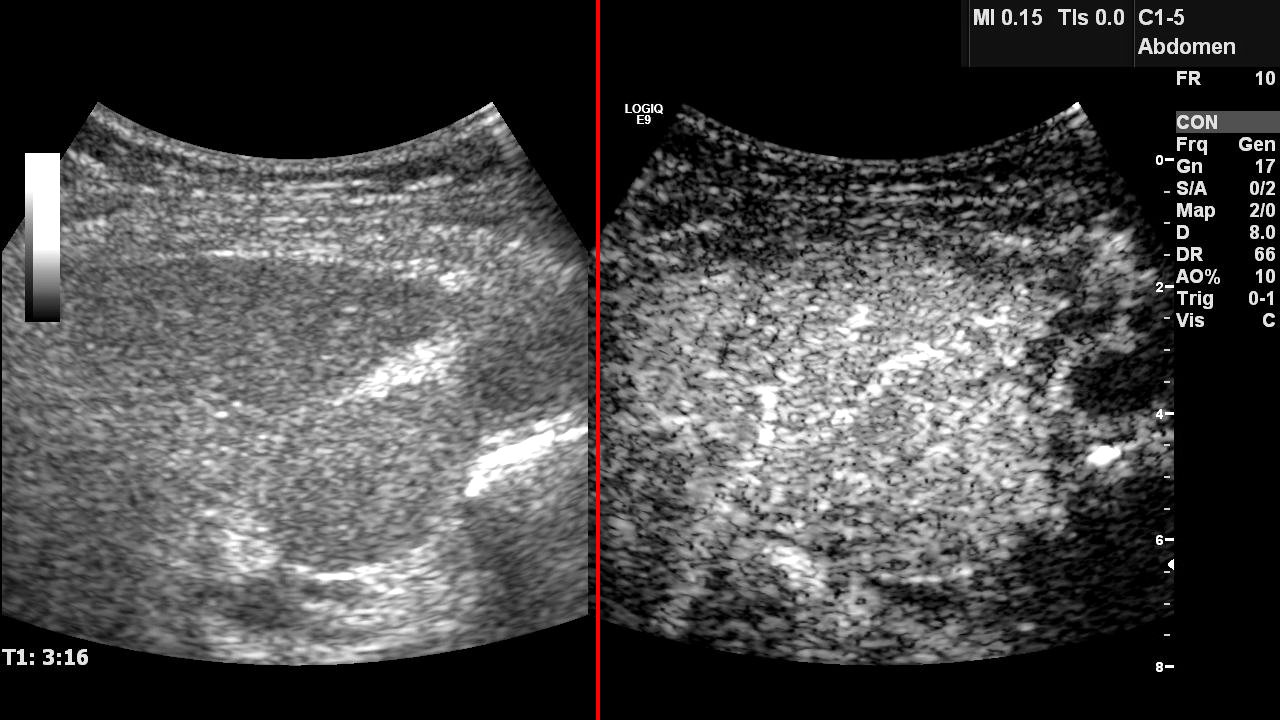

In [93]:
test_split_col = (
    test_split_result[
        "estimated_split_column"
    ]
)


test_annotated = (
    Image.open(
        test_candidate[
            "preview_path"
        ]
    )
    .convert(
        "RGB"
    )
)


draw = ImageDraw.Draw(
    test_annotated
)


draw.line(
    [
        (
            test_split_col,
            0,
        ),
        (
            test_split_col,
            test_annotated.height,
        ),
    ],
    fill=(
        255,
        0,
        0,
    ),
    width=4,
)


display(
    test_annotated
)

In [94]:
def process_split_candidate(
    row: pd.Series,
) -> dict:

    preview_path = Path(
        row[
            "preview_path"
        ]
    )


    image_gray = np.array(
        Image.open(
            preview_path
        )
        .convert(
            "L"
        )
    )


    split_result = (
        estimate_split_column(
            image_gray
        )
    )


    split_column = (
        split_result[
            "estimated_split_column"
        ]
    )


    height, width = (
        image_gray.shape
    )


    # ----------------------------------
    # Candidate crops
    # ----------------------------------

    left_panel = (
        image_gray[
            :,
            :split_column
        ]
    )


    right_panel = (
        image_gray[
            :,
            split_column:
        ]
    )


    patient_id = str(
        row[
            "PatientID"
        ]
    )


    sop_uid = str(
        row[
            "SOPInstanceUID"
        ]
    )


    safe_uid = (
        sop_uid
        .replace(
            "/",
            "_",
        )
        .replace(
            "\\",
            "_",
        )
    )


    base_name = (
        f"{patient_id}__"
        f"{safe_uid}"
    )


    # ----------------------------------
    # Save left/right candidate panels
    # ----------------------------------

    left_path = (
        LEFT_PANEL_DIR
        / f"{base_name}__left_candidate.png"
    )


    right_path = (
        RIGHT_PANEL_DIR
        / f"{base_name}__right_candidate.png"
    )


    Image.fromarray(
        left_panel
    ).save(
        left_path
    )


    Image.fromarray(
        right_panel
    ).save(
        right_path
    )


    # ----------------------------------
    # Annotated original
    # ----------------------------------

    annotated = (
        Image.fromarray(
            image_gray
        )
        .convert(
            "RGB"
        )
    )


    draw = ImageDraw.Draw(
        annotated
    )


    draw.line(
        [
            (
                split_column,
                0,
            ),
            (
                split_column,
                height,
            ),
        ],
        fill=(
            255,
            0,
            0,
        ),
        width=4,
    )


    label_text = (
        f"split={split_column} | "
        f"conf="
        f"{split_result['split_confidence_score']:.3f} | "
        f"{split_result['split_confidence_tier']}"
    )


    draw.text(
        (
            10,
            10,
        ),
        label_text,
        fill=(
            255,
            0,
            0,
        ),
    )


    annotated_path = (
        ANNOTATED_SPLIT_DIR
        / f"{base_name}__annotated.png"
    )


    annotated.save(
        annotated_path
    )


    result = {
        "PatientID":
            patient_id,

        "source_SeriesInstanceUID":
            row[
                "source_SeriesInstanceUID"
            ],

        "SOPInstanceUID":
            sop_uid,

        "source_dicom_path":
            row[
                "path"
            ],

        "source_preview_path":
            str(
                preview_path
            ),

        "temporal_type":
            row[
                "temporal_type"
            ],

        "aspect_ratio":
            float(
                row[
                    "aspect_ratio"
                ]
            ),

        "frame_width":
            int(
                width
            ),

        "frame_height":
            int(
                height
            ),

        **split_result,

        "annotated_preview_path":
            str(
                annotated_path
            ),

        "left_panel_candidate_path":
            str(
                left_path
            ),

        "right_panel_candidate_path":
            str(
                right_path
            ),

        "automatic_status":
            "split_candidate",

        "manual_split_valid":
            "",

        "manual_panel_semantics":
            "",

        "manual_notes":
            "",
    }


    return result

In [95]:
split_rows = []


total_candidates = len(
    wide_candidates_df
)


for index, row in (
    wide_candidates_df
    .iterrows()
):

    print(
        f"\rProcessing split candidate "
        f"{index + 1}/{total_candidates}",
        end="",
    )


    result = (
        process_split_candidate(
            row
        )
    )


    split_rows.append(
        result
    )


print(
    "\nSplit candidate processing complete."
)


split_validation_df = (
    pd.DataFrame(
        split_rows
    )
)


split_validation_df.to_csv(
    SPLIT_VALIDATION_PATH,
    index=False,
)


print(
    "\n=== SPLIT PROCESSING SUMMARY ==="
)


print(
    "Candidates processed:",
    len(
        split_validation_df
    )
)


print(
    "\nConfidence tiers:"
)


print(
    split_validation_df[
        "split_confidence_tier"
    ]
    .value_counts(
        dropna=False
    )
)


print(
    "\nSaved:"
)

print(
    SPLIT_VALIDATION_PATH
)

Processing split candidate 83/83
Split candidate processing complete.

=== SPLIT PROCESSING SUMMARY ===
Candidates processed: 83

Confidence tiers:
split_confidence_tier
high      76
low        5
medium     2
Name: count, dtype: int64

Saved:
/kaggle/working/project_rooting_week2/data-manifests/split_validation_week2.csv


In [96]:
print(
    "=== SPLIT FRACTION SUMMARY ==="
)


display(
    split_validation_df[
        [
            "split_fraction",
            "split_confidence_score",
            "valley_depth_score",
            "center_score",
            "balance_score",
        ]
    ]
    .describe()
    .T
)

=== SPLIT FRACTION SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
split_fraction,83.0,0.508601,0.045726,0.451562,0.473582,0.507692,0.512821,0.649219
split_confidence_score,83.0,0.862747,0.204096,0.082349,0.874731,0.940916,0.971022,0.979649
valley_depth_score,83.0,0.880731,0.236433,0.000000,0.943768,0.987021,0.999986,1.000000
center_score,83.0,0.800660,0.236716,0.005208,0.776042,0.868946,0.920640,0.982456
balance_score,83.0,0.894292,0.108223,0.540313,0.874085,0.924342,0.953491,0.989529


In [97]:
suspicious_split_df = (
    split_validation_df[
        (
            split_validation_df[
                "split_fraction"
            ]
            < 0.40
        )
        |
        (
            split_validation_df[
                "split_fraction"
            ]
            > 0.60
        )
        |
        (
            split_validation_df[
                "split_confidence_tier"
            ]
            == "low"
        )
    ]
    .copy()
)


print(
    "Suspicious or low-confidence splits:",
    len(
        suspicious_split_df
    )
)


display(
    suspicious_split_df[
        [
            "PatientID",
            "aspect_ratio",
            "split_fraction",
            "split_confidence_score",
            "split_confidence_tier",
            "annotated_preview_path",
        ]
    ]
)

Suspicious or low-confidence splits: 6


,PatientID,aspect_ratio,split_fraction,split_confidence_score,split_confidence_tier,annotated_preview_path
37,LiverUS-73,1.7778,0.649219,0.571576,medium,/kaggle/working/project_rooting_week2/qc/week2...
51,LiverUS-118,1.7778,0.649219,0.082349,low,/kaggle/working/project_rooting_week2/qc/week2...
54,LiverUS-118,1.7778,0.649219,0.082349,low,/kaggle/working/project_rooting_week2/qc/week2...
59,LiverUS-118,1.7778,0.649219,0.082349,low,/kaggle/working/project_rooting_week2/qc/week2...
60,LiverUS-118,1.7778,0.649219,0.190141,low,/kaggle/working/project_rooting_week2/qc/week2...
72,LiverUS-76,1.6000,0.648840,0.355391,low,/kaggle/working/project_rooting_week2/qc/week2...


In [98]:
AUDIT_SIZE = min(
    20,
    len(
        split_validation_df
    ),
)


audit_parts = []


for tier in [
    "low",
    "medium",
    "high",
]:

    tier_df = (
        split_validation_df[
            split_validation_df[
                "split_confidence_tier"
            ]
            == tier
        ]
        .copy()
    )


    if len(
        tier_df
    ) == 0:

        continue


    n_take = min(
        7,
        len(
            tier_df
        ),
    )


    sampled = (
        tier_df
        .sample(
            n=n_take,
            random_state=42,
        )
    )


    audit_parts.append(
        sampled
    )


if audit_parts:

    audit_df = (
        pd.concat(
            audit_parts,
            ignore_index=True,
        )
        .drop_duplicates(
            subset=[
                "SOPInstanceUID"
            ]
        )
    )

else:

    audit_df = (
        split_validation_df
        .head(
            AUDIT_SIZE
        )
        .copy()
    )


if len(
    audit_df
) < AUDIT_SIZE:

    remaining_needed = (
        AUDIT_SIZE
        - len(
            audit_df
        )
    )


    remaining_pool = (
        split_validation_df[
            ~split_validation_df[
                "SOPInstanceUID"
            ]
            .isin(
                audit_df[
                    "SOPInstanceUID"
                ]
            )
        ]
    )


    extra_df = (
        remaining_pool
        .sample(
            n=min(
                remaining_needed,
                len(
                    remaining_pool
                ),
            ),
            random_state=42,
        )
    )


    audit_df = pd.concat(
        [
            audit_df,
            extra_df,
        ],
        ignore_index=True,
    )


audit_df = (
    audit_df
    .head(
        AUDIT_SIZE
    )
    .reset_index(
        drop=True
    )
)


audit_df.insert(
    0,
    "audit_id",
    [
        f"AUDIT_{i:03d}"
        for i in range(
            1,
            len(audit_df) + 1
        )
    ],
)


audit_df[
    "review_status"
] = "pending"


audit_df[
    "manual_split_valid"
] = ""


audit_df[
    "manual_panel_semantics"
] = ""


audit_df[
    "manual_notes"
] = ""


audit_df.to_csv(
    SPLIT_AUDIT_PATH,
    index=False,
)


print(
    "Manual audit images:",
    len(
        audit_df
    )
)


print(
    "\nConfidence distribution:"
)


print(
    audit_df[
        "split_confidence_tier"
    ]
    .value_counts()
)


display(
    audit_df[
        [
            "audit_id",
            "PatientID",
            "temporal_type",
            "split_fraction",
            "split_confidence_score",
            "split_confidence_tier",
            "review_status",
        ]
    ]
)

Manual audit images: 20

Confidence distribution:
split_confidence_tier
high      13
low        5
medium     2
Name: count, dtype: int64


,audit_id,PatientID,temporal_type,split_fraction,split_confidence_score,split_confidence_tier,review_status
0,AUDIT_001,LiverUS-118,single_frame,0.649219,0.082349,low,pending
1,AUDIT_002,LiverUS-76,single_frame,0.648840,0.355391,low,pending
2,AUDIT_003,LiverUS-118,single_frame,0.649219,0.082349,low,pending
3,AUDIT_004,LiverUS-118,single_frame,0.649219,0.082349,low,pending
4,AUDIT_005,LiverUS-118,single_frame,0.649219,0.190141,low,pending
5,AUDIT_006,LiverUS-73,single_frame,0.649219,0.571576,medium,pending
6,AUDIT_007,LiverUS-86,single_frame,0.455469,0.635401,medium,pending
7,AUDIT_008,LiverUS-86,single_frame,0.466406,0.859752,high,pending
8,AUDIT_009,LiverUS-84,single_frame,0.466406,0.901599,high,pending
9,AUDIT_010,LiverUS-86,multi_frame_cine,0.506579,0.754820,high,pending


In [102]:
audit_image_paths = [
    Path(path)
    for path
    in audit_df[
        "annotated_preview_path"
    ]
    .tolist()
]


audit_labels = [
    (
        f"{row.audit_id} | "
        f"{row.PatientID} | "
        f"{row.split_confidence_tier} | "
        f"{row.split_confidence_score:.2f}"
    )

    for row
    in audit_df.itertuples()
]


AUDIT_CONTACT_SHEET_PATH = (
    AUDIT_CONTACT_DIR
    / "day4_split_audit_contact_sheet.png"
)


make_contact_sheet(
    image_paths=
        audit_image_paths,

    labels=
        audit_labels,

    output_path=
        AUDIT_CONTACT_SHEET_PATH,

    columns=4,
)


print(
    "Audit contact sheet:"
)

print(
    AUDIT_CONTACT_SHEET_PATH
)


print(
    "Exists:",
    AUDIT_CONTACT_SHEET_PATH.exists()
)

Audit contact sheet:
/kaggle/working/project_rooting_week2/qc/week2_split_validation/audit_contact_sheets/day4_split_audit_contact_sheet.png
Exists: True


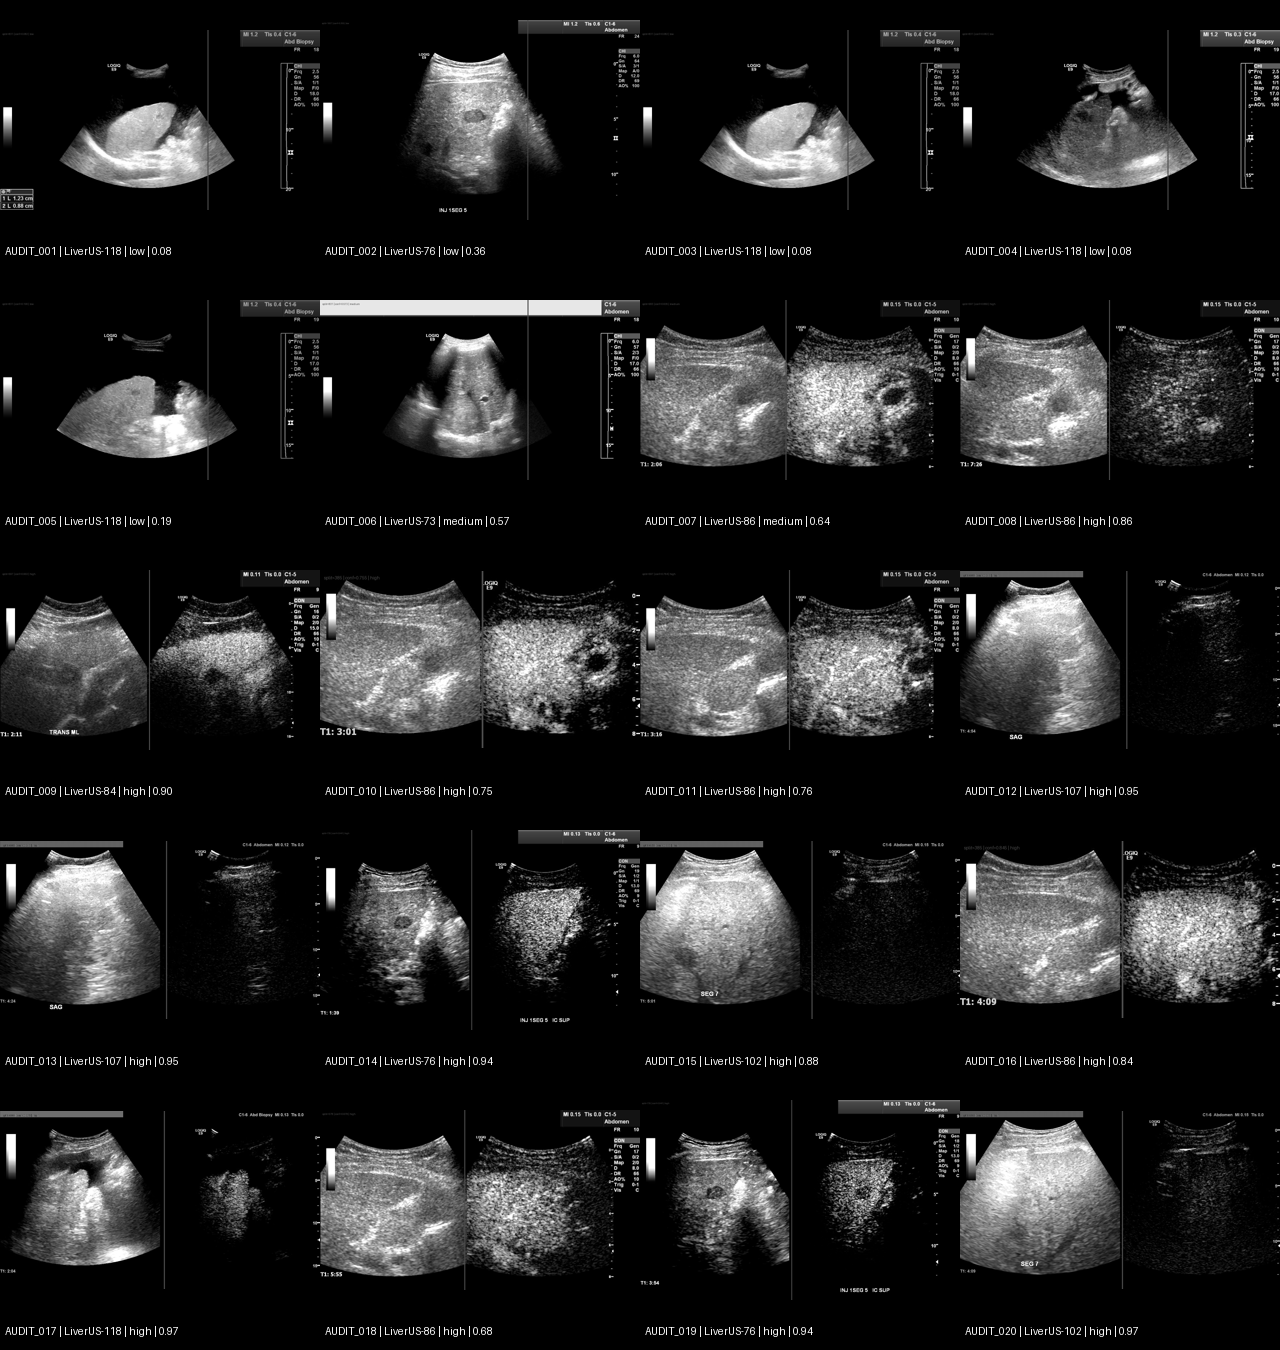

In [103]:
display(
    Image.open(
        AUDIT_CONTACT_SHEET_PATH
    )
)

In [104]:
invalid_audit_ids = {
    "AUDIT_001",
    "AUDIT_002",
    "AUDIT_003",
    "AUDIT_004",
    "AUDIT_005",
    "AUDIT_006",
}


valid_audit_ids = set(
    audit_df["audit_id"]
) - invalid_audit_ids


# ----------------------------------
# Initialize reviewer fields
# ----------------------------------

audit_df["review_status"] = "reviewed"

audit_df["manual_split_valid"] = False

audit_df["manual_panel_semantics"] = ""

audit_df["manual_notes"] = ""


# ----------------------------------
# Invalid examples
# ----------------------------------

invalid_mask = (
    audit_df["audit_id"]
    .isin(invalid_audit_ids)
)


audit_df.loc[
    invalid_mask,
    "manual_split_valid"
] = False


audit_df.loc[
    invalid_mask,
    "manual_panel_semantics"
] = "not_applicable"


audit_df.loc[
    invalid_mask,
    "manual_notes"
] = (
    "Single ultrasound view with UI/control region; "
    "automatic split does not separate two ultrasound panels."
)


# ----------------------------------
# Valid dual-panel examples
# ----------------------------------

valid_mask = (
    audit_df["audit_id"]
    .isin(valid_audit_ids)
)


audit_df.loc[
    valid_mask,
    "manual_split_valid"
] = True


audit_df.loc[
    valid_mask,
    "manual_panel_semantics"
] = (
    "left_bmode_like__right_ceus_like"
)


audit_df.loc[
    valid_mask,
    "manual_notes"
] = (
    "Two ultrasound panels are visually present and "
    "the estimated separator is plausible. "
    "Panel modality semantics remain candidate-level."
)


audit_df.to_csv(
    SPLIT_AUDIT_PATH,
    index=False,
)


print("=== MANUAL AUDIT RESULTS ===")

print(
    audit_df[
        "manual_split_valid"
    ]
    .value_counts()
)


display(
    audit_df[
        [
            "audit_id",
            "PatientID",
            "split_confidence_tier",
            "split_confidence_score",
            "manual_split_valid",
            "manual_panel_semantics",
        ]
    ]
)

=== MANUAL AUDIT RESULTS ===
manual_split_valid
True     14
False     6
Name: count, dtype: int64


,audit_id,PatientID,split_confidence_tier,split_confidence_score,manual_split_valid,manual_panel_semantics
0,AUDIT_001,LiverUS-118,low,0.082349,False,not_applicable
1,AUDIT_002,LiverUS-76,low,0.355391,False,not_applicable
2,AUDIT_003,LiverUS-118,low,0.082349,False,not_applicable
3,AUDIT_004,LiverUS-118,low,0.082349,False,not_applicable
4,AUDIT_005,LiverUS-118,low,0.190141,False,not_applicable
5,AUDIT_006,LiverUS-73,medium,0.571576,False,not_applicable
6,AUDIT_007,LiverUS-86,medium,0.635401,True,left_bmode_like__right_ceus_like
7,AUDIT_008,LiverUS-86,high,0.859752,True,left_bmode_like__right_ceus_like
8,AUDIT_009,LiverUS-84,high,0.901599,True,left_bmode_like__right_ceus_like
9,AUDIT_010,LiverUS-86,high,0.754820,True,left_bmode_like__right_ceus_like


In [105]:
split_validation_df[
    "split_boundary_flag"
] = (
    (
        split_validation_df[
            "split_fraction"
        ] <= 0.38
    )
    |
    (
        split_validation_df[
            "split_fraction"
        ] >= 0.62
    )
)


print(
    "Boundary-flagged splits:",
    int(
        split_validation_df[
            "split_boundary_flag"
        ].sum()
    )
)


display(
    split_validation_df[
        split_validation_df[
            "split_boundary_flag"
        ]
    ][
        [
            "PatientID",
            "split_fraction",
            "split_confidence_score",
            "split_confidence_tier",
        ]
    ]
)

Boundary-flagged splits: 6


,PatientID,split_fraction,split_confidence_score,split_confidence_tier
37,LiverUS-73,0.649219,0.571576,medium
51,LiverUS-118,0.649219,0.082349,low
54,LiverUS-118,0.649219,0.082349,low
59,LiverUS-118,0.649219,0.082349,low
60,LiverUS-118,0.649219,0.190141,low
72,LiverUS-76,0.648840,0.355391,low


In [106]:
# Initialize review columns

split_validation_df[
    "review_status"
] = "not_manually_reviewed"


split_validation_df[
    "manual_split_valid"
] = pd.NA


split_validation_df[
    "manual_panel_semantics"
] = ""


split_validation_df[
    "manual_notes"
] = ""


# ----------------------------------
# Transfer audit decisions
# ----------------------------------

for _, audit_row in audit_df.iterrows():

    mask = (
        split_validation_df[
            "SOPInstanceUID"
        ]
        ==
        audit_row[
            "SOPInstanceUID"
        ]
    )


    split_validation_df.loc[
        mask,
        "review_status"
    ] = "reviewed"


    split_validation_df.loc[
        mask,
        "manual_split_valid"
    ] = bool(
        audit_row[
            "manual_split_valid"
        ]
    )


    split_validation_df.loc[
        mask,
        "manual_panel_semantics"
    ] = audit_row[
        "manual_panel_semantics"
    ]


    split_validation_df.loc[
        mask,
        "manual_notes"
    ] = audit_row[
        "manual_notes"
    ]


print(
    split_validation_df[
        "review_status"
    ]
    .value_counts()
)

review_status
not_manually_reviewed    63
reviewed                 20
Name: count, dtype: int64


In [107]:
def determine_final_split_status(
    row: pd.Series,
) -> str:

    # ----------------------------------
    # Manual decision has priority
    # ----------------------------------

    if row[
        "review_status"
    ] == "reviewed":

        if (
            row[
                "manual_split_valid"
            ]
            == True
        ):

            return (
                "accepted_manual_review"
            )

        else:

            return (
                "rejected_manual_review"
            )


    # ----------------------------------
    # Non-reviewed cases
    # ----------------------------------

    if (
        row[
            "split_confidence_tier"
        ] == "high"

        and

        not bool(
            row[
                "split_boundary_flag"
            ]
        )
    ):

        return (
            "accepted_auto_high_confidence"
        )


    return (
        "pending_manual_review"
    )

In [108]:
split_validation_df[
    "final_split_status"
] = (
    split_validation_df
    .apply(
        determine_final_split_status,
        axis=1,
    )
)


split_validation_df[
    "final_split_valid"
] = (
    split_validation_df[
        "final_split_status"
    ]
    .isin([
        "accepted_manual_review",
        "accepted_auto_high_confidence",
    ])
)


print(
    "=== FINAL SPLIT STATUS ==="
)


print(
    split_validation_df[
        "final_split_status"
    ]
    .value_counts()
)


print(
    "\nFinal valid split candidates:",
    int(
        split_validation_df[
            "final_split_valid"
        ].sum()
    )
)


print(
    "Rejected / pending:",
    int(
        (
            ~split_validation_df[
                "final_split_valid"
            ]
        ).sum()
    )
)

=== FINAL SPLIT STATUS ===
final_split_status
accepted_auto_high_confidence    63
accepted_manual_review           14
rejected_manual_review            6
Name: count, dtype: int64

Final valid split candidates: 77
Rejected / pending: 6


In [109]:
split_validation_df.to_csv(
    SPLIT_VALIDATION_PATH,
    index=False,
)


print(
    "Final split validation saved:"
)

print(
    SPLIT_VALIDATION_PATH
)


print(
    "Rows:",
    len(
        split_validation_df
    )
)


print(
    "Final valid candidates:",
    int(
        split_validation_df[
            "final_split_valid"
        ].sum()
    )
)

Final split validation saved:
/kaggle/working/project_rooting_week2/data-manifests/split_validation_week2.csv
Rows: 83
Final valid candidates: 77


In [110]:
day4_summary = {
    "created_at":
        datetime.now().isoformat(),

    "week":
        "Week 2",

    "day":
        "Day 4",

    "wide_candidates":
        int(
            len(
                wide_candidates_df
            )
        ),

    "split_candidates_processed":
        int(
            len(
                split_validation_df
            )
        ),

    "confidence_tiers": {
        key: int(value)

        for key, value in (
            split_validation_df[
                "split_confidence_tier"
            ]
            .value_counts()
            .to_dict()
            .items()
        )
    },

    "manual_audit_items":
        int(
            len(
                audit_df
            )
        ),

    "manual_valid":
        int(
            audit_df[
                "manual_split_valid"
            ].sum()
        ),

    "manual_invalid":
        int(
            (
                ~audit_df[
                    "manual_split_valid"
                ]
            ).sum()
        ),

    "boundary_flagged":
        int(
            split_validation_df[
                "split_boundary_flag"
            ].sum()
        ),

    "final_valid_split_candidates":
        int(
            split_validation_df[
                "final_split_valid"
            ].sum()
        ),

    "final_status_counts": {
        key: int(value)

        for key, value in (
            split_validation_df[
                "final_split_status"
            ]
            .value_counts()
            .to_dict()
            .items()
        )
    },

    "outputs": {
        "split_validation":
            str(
                SPLIT_VALIDATION_PATH
            ),

        "manual_audit":
            str(
                SPLIT_AUDIT_PATH
            ),

        "annotated_previews":
            str(
                ANNOTATED_SPLIT_DIR
            ),

        "left_panel_candidates":
            str(
                LEFT_PANEL_DIR
            ),

        "right_panel_candidates":
            str(
                RIGHT_PANEL_DIR
            ),

        "audit_contact_sheet":
            str(
                AUDIT_CONTACT_SHEET_PATH
            ),
    },

    "next_step": (
        "Day 5: generate pairing candidates from "
        "validated split cases, preserve pairing rationale "
        "and confidence, create Week 2 compatibility datalist, "
        "and run validation tests."
    ),
}


with open(
    DAY4_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        day4_summary,
        file,
        indent=2,
    )


print(
    json.dumps(
        day4_summary,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T20:26:50.265485",
  "week": "Week 2",
  "day": "Day 4",
  "wide_candidates": 83,
  "split_candidates_processed": 83,
  "confidence_tiers": {
    "high": 76,
    "low": 5,
    "medium": 2
  },
  "manual_audit_items": 20,
  "manual_valid": 14,
  "manual_invalid": 6,
  "boundary_flagged": 6,
  "final_valid_split_candidates": 77,
  "final_status_counts": {
    "accepted_auto_high_confidence": 63,
    "accepted_manual_review": 14,
    "rejected_manual_review": 6
  },
  "outputs": {
    "split_validation": "/kaggle/working/project_rooting_week2/data-manifests/split_validation_week2.csv",
    "manual_audit": "/kaggle/working/project_rooting_week2/data-manifests/split_manual_audit_week2.csv",
    "annotated_previews": "/kaggle/working/project_rooting_week2/qc/week2_split_validation/annotated",
    "left_panel_candidates": "/kaggle/working/project_rooting_week2/qc/week2_split_validation/left_panel_candidates",
    "right_panel_candidates": "/kaggle/working/project_

In [111]:
pending_count = int(
    (
        split_validation_df[
            "final_split_status"
        ]
        == "pending_manual_review"
    ).sum()
)


day4_go = (

    len(
        split_validation_df
    )
    ==
    len(
        wide_candidates_df
    )

    and

    len(
        audit_df
    )
    == 20

    and

    (
        audit_df[
            "review_status"
        ]
        == "reviewed"
    ).all()

    and

    split_validation_df[
        "final_split_valid"
    ].sum() > 0

    and

    pending_count == 0

    and

    SPLIT_VALIDATION_PATH.exists()

    and

    SPLIT_AUDIT_PATH.exists()
)


print("=" * 70)


print(
    "DAY 4 GO/NO-GO:",
    "GO"
    if day4_go
    else "NO-GO"
)


print("=" * 70)


print(
    "Candidates processed:",
    len(
        split_validation_df
    )
)


print(
    "Manual audit reviewed:",
    int(
        (
            audit_df[
                "review_status"
            ]
            == "reviewed"
        ).sum()
    ),
    "/",
    len(
        audit_df
    )
)


print(
    "Final valid split candidates:",
    int(
        split_validation_df[
            "final_split_valid"
        ].sum()
    )
)


print(
    "Pending review:",
    pending_count
)

DAY 4 GO/NO-GO: GO
Candidates processed: 83
Manual audit reviewed: 20 / 20
Final valid split candidates: 77
Pending review: 0


# Day 5 - Pairing Candidates, Temporal Samples, and Dataset Validation

## Goal

Convert validated intra-DICOM dual-panel split candidates into a traceable pairing-candidate dataset, export representative paired samples and controlled temporal clips, create pairing QC examples, build a MONAI-compatible draft datalist, and run final Week 2 validation tests.

## Expected Outputs

- `pairing_candidates_week2.csv`
- `paired_cases.csv`
- `temporal_clip_manifest_week2.csv`
- `monai_items_week2.csv`
- `monai_dataset_week2.json`
- `validation_report_week2.json`
- `week2_day5_summary.json`
- paired sample images
- controlled temporal clip samples
- QC pairing examples

## Scientific Boundary

Validated splits are treated as pairing candidates, not as automatic ground-truth modality labels.

Panel order and modality semantics remain candidate-level unless explicitly verified.

In [112]:
PAIRING_CANDIDATES_PATH = (
    MANIFEST_DIR
    / "pairing_candidates_week2.csv"
)

PAIRED_CASES_PATH = (
    MANIFEST_DIR
    / "paired_cases.csv"
)

TEMPORAL_CLIP_MANIFEST_PATH = (
    MANIFEST_DIR
    / "temporal_clip_manifest_week2.csv"
)

MONAI_ITEMS_PATH = (
    MANIFEST_DIR
    / "monai_items_week2.csv"
)

MONAI_DATASET_PATH = (
    MANIFEST_DIR
    / "monai_dataset_week2.json"
)

VALIDATION_REPORT_PATH = (
    MANIFEST_DIR
    / "validation_report_week2.json"
)

DAY5_SUMMARY_PATH = (
    MANIFEST_DIR
    / "week2_day5_summary.json"
)


PAIRED_SAMPLE_DIR = (
    DERIVED_DIR
    / "week2_paired_samples"
)

TEMPORAL_CLIP_DIR = (
    DERIVED_DIR
    / "week2_temporal_clips"
)

QC_PAIRING_DIR = (
    QC_DIR
    / "qc_pairing_examples"
)


for directory in [
    PAIRED_SAMPLE_DIR,
    TEMPORAL_CLIP_DIR,
    QC_PAIRING_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=== DAY 5 PATHS ===")

print(
    "Pairing candidates:",
    PAIRING_CANDIDATES_PATH
)

print(
    "Paired cases:",
    PAIRED_CASES_PATH
)

print(
    "Temporal clips:",
    TEMPORAL_CLIP_DIR
)

print(
    "MONAI items:",
    MONAI_ITEMS_PATH
)

print(
    "Validation report:",
    VALIDATION_REPORT_PATH
)

=== DAY 5 PATHS ===
Pairing candidates: /kaggle/working/project_rooting_week2/data-manifests/pairing_candidates_week2.csv
Paired cases: /kaggle/working/project_rooting_week2/data-manifests/paired_cases.csv
Temporal clips: /kaggle/working/project_rooting_week2/derived/week2_temporal_clips
MONAI items: /kaggle/working/project_rooting_week2/data-manifests/monai_items_week2.csv
Validation report: /kaggle/working/project_rooting_week2/data-manifests/validation_report_week2.json


In [113]:
accepted_split_df = (
    split_validation_df[
        split_validation_df[
            "final_split_valid"
        ]
    ]
    .copy()
    .sort_values(
        [
            "PatientID",
            "SOPInstanceUID",
        ]
    )
    .reset_index(drop=True)
)


print("=== ACCEPTED SPLIT INPUT ===")

print(
    "Accepted split candidates:",
    len(accepted_split_df)
)

print(
    "Patients represented:",
    accepted_split_df[
        "PatientID"
    ].nunique()
)

print(
    "\nSource status distribution:"
)

print(
    accepted_split_df[
        "final_split_status"
    ]
    .value_counts()
)

=== ACCEPTED SPLIT INPUT ===
Accepted split candidates: 77
Patients represented: 10

Source status distribution:
final_split_status
accepted_auto_high_confidence    63
accepted_manual_review           14
Name: count, dtype: int64


In [114]:
def extract_original_representative_frame(
    dicom_path: Path,
):

    ds = pydicom.dcmread(
        str(dicom_path)
    )

    pixel_array = np.asarray(
        ds.pixel_array
    )

    number_of_frames = int(
        getattr(
            ds,
            "NumberOfFrames",
            1,
        )
    )


    if number_of_frames > 1:

        frame_index = (
            number_of_frames // 2
        )

        frame = pixel_array[
            frame_index
        ]

    else:

        frame_index = 0
        frame = pixel_array


    frame = np.asarray(
        frame
    )


    # Handle channel-first color arrays if encountered

    if (
        frame.ndim == 3
        and
        frame.shape[0] in (3, 4)
        and
        frame.shape[-1] not in (3, 4)
    ):

        frame = np.moveaxis(
            frame,
            0,
            -1,
        )


    frame_uint8 = normalize_to_uint8(
        frame
    )


    if (
        str(
            getattr(
                ds,
                "PhotometricInterpretation",
                "",
            )
        )
        == "MONOCHROME1"
    ):

        frame_uint8 = (
            255
            - frame_uint8
        )


    if (
        frame_uint8.ndim == 3
        and
        frame_uint8.shape[-1] == 4
    ):

        frame_uint8 = (
            frame_uint8[
                ...,
                :3
            ]
        )


    return (
        frame_uint8,
        frame_index,
        number_of_frames,
    )

In [115]:
import shutil


pairing_rows = []


for index, row in (
    accepted_split_df
    .iterrows()
):

    pair_id = (
        f"W2PAIR_{index + 1:04d}"
    )


    pair_dir = (
        PAIRED_SAMPLE_DIR
        / pair_id
    )


    pair_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    source_dicom_path = Path(
        row[
            "source_dicom_path"
        ]
    )


    frame_uint8, frame_index, number_of_frames = (
        extract_original_representative_frame(
            source_dicom_path
        )
    )


    frame_height = (
        frame_uint8.shape[0]
    )

    frame_width = (
        frame_uint8.shape[1]
    )


    split_fraction = float(
        row[
            "split_fraction"
        ]
    )


    split_column = int(
        round(
            frame_width
            * split_fraction
        )
    )


    split_column = int(
        np.clip(
            split_column,
            1,
            frame_width - 1,
        )
    )


    panel_a = (
        frame_uint8[
            :,
            :split_column,
            ...
        ]
    )


    panel_b = (
        frame_uint8[
            :,
            split_column:,
            ...
        ]
    )


    panel_a_path = (
        pair_dir
        / "panel_a_candidate.png"
    )


    panel_b_path = (
        pair_dir
        / "panel_b_candidate.png"
    )


    Image.fromarray(
        panel_a
    ).save(
        panel_a_path
    )


    Image.fromarray(
        panel_b
    ).save(
        panel_b_path
    )


    if (
        row[
            "final_split_status"
        ]
        ==
        "accepted_manual_review"
    ):

        pairing_reason = (
            "same_dicom_same_frame_"
            "manual_split_validation"
        )

        semantic_review_status = (
            "manual_candidate_level"
        )

    else:

        pairing_reason = (
            "same_dicom_same_frame_"
            "automatic_high_confidence_split"
        )

        semantic_review_status = (
            "not_manually_verified"
        )


    manual_semantics = (
        row.get(
            "manual_panel_semantics",
            "",
        )
    )


    if pd.isna(
        manual_semantics
    ):

        manual_semantics = ""


    pairing_rows.append({

        "pair_id":
            pair_id,

        "PatientID":
            row[
                "PatientID"
            ],

        "source_SeriesInstanceUID":
            row[
                "source_SeriesInstanceUID"
            ],

        "SOPInstanceUID":
            row[
                "SOPInstanceUID"
            ],

        "source_dicom_path":
            str(
                source_dicom_path
            ),

        "representative_frame_index":
            int(
                frame_index
            ),

        "NumberOfFrames":
            int(
                number_of_frames
            ),

        "temporal_type":
            row[
                "temporal_type"
            ],

        "split_fraction":
            float(
                split_fraction
            ),

        "split_confidence_score":
            float(
                row[
                    "split_confidence_score"
                ]
            ),

        "split_confidence_tier":
            row[
                "split_confidence_tier"
            ],

        "split_validation_status":
            row[
                "final_split_status"
            ],

        "pairing_reason":
            pairing_reason,

        "pairing_level":
            "intra_dicom_same_frame",

        "pairing_status":
            "candidate_not_ground_truth",

        "semantic_review_status":
            semantic_review_status,

        "manual_panel_semantics_note":
            manual_semantics,

        "panel_a_candidate_path":
            str(
                panel_a_path
            ),

        "panel_b_candidate_path":
            str(
                panel_b_path
            ),

        "panel_a_relative_path":
            str(
                panel_a_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "panel_b_relative_path":
            str(
                panel_b_path.relative_to(
                    PROJECT_ROOT
                )
            ),
    })


pairing_candidates_df = (
    pd.DataFrame(
        pairing_rows
    )
)


pairing_candidates_df.to_csv(
    PAIRING_CANDIDATES_PATH,
    index=False,
)


print(
    "=== PAIRING CANDIDATE EXPORT ==="
)


print(
    "Pairing candidates:",
    len(
        pairing_candidates_df
    )
)


print(
    "Patients represented:",
    pairing_candidates_df[
        "PatientID"
    ].nunique()
)


print(
    "Panel A files:",
    len(
        list(
            PAIRED_SAMPLE_DIR.rglob(
                "panel_a_candidate.png"
            )
        )
    )
)


print(
    "Panel B files:",
    len(
        list(
            PAIRED_SAMPLE_DIR.rglob(
                "panel_b_candidate.png"
            )
        )
    )
)


print(
    "\nSaved:",
    PAIRING_CANDIDATES_PATH
)

=== PAIRING CANDIDATE EXPORT ===
Pairing candidates: 77
Patients represented: 10
Panel A files: 77
Panel B files: 77

Saved: /kaggle/working/project_rooting_week2/data-manifests/pairing_candidates_week2.csv


In [116]:
pairing_candidates_df[
    "panel_a_exists"
] = (
    pairing_candidates_df[
        "panel_a_candidate_path"
    ]
    .map(
        lambda path:
            Path(path).exists()
    )
)


pairing_candidates_df[
    "panel_b_exists"
] = (
    pairing_candidates_df[
        "panel_b_candidate_path"
    ]
    .map(
        lambda path:
            Path(path).exists()
    )
)


pairing_candidates_df[
    "pair_paths_valid"
] = (
    pairing_candidates_df[
        "panel_a_exists"
    ]
    &
    pairing_candidates_df[
        "panel_b_exists"
    ]
)


print("=== PAIR INTEGRITY CHECK ===")


print(
    "Pairs:",
    len(
        pairing_candidates_df
    )
)


print(
    "Unique pair IDs:",
    pairing_candidates_df[
        "pair_id"
    ].nunique()
)


print(
    "Valid panel paths:",
    int(
        pairing_candidates_df[
            "pair_paths_valid"
        ].sum()
    ),
    "/",
    len(
        pairing_candidates_df
    )
)


print(
    "Duplicate source SOP UIDs:",
    int(
        pairing_candidates_df[
            "SOPInstanceUID"
        ]
        .duplicated()
        .sum()
    )
)

=== PAIR INTEGRITY CHECK ===
Pairs: 77
Unique pair IDs: 77
Valid panel paths: 77 / 77
Duplicate source SOP UIDs: 0


In [117]:
paired_cases_df = (
    pairing_candidates_df
    .groupby(
        "PatientID"
    )
    .agg(
        pair_candidate_count=(
            "pair_id",
            "count",
        ),

        single_frame_pairs=(
            "temporal_type",
            lambda x:
                int(
                    (
                        x
                        == "single_frame"
                    ).sum()
                ),
        ),

        multi_frame_pairs=(
            "temporal_type",
            lambda x:
                int(
                    (
                        x
                        == "multi_frame_cine"
                    ).sum()
                ),
        ),

        manual_review_accepted=(
            "split_validation_status",
            lambda x:
                int(
                    (
                        x
                        == "accepted_manual_review"
                    ).sum()
                ),
        ),

        auto_high_confidence_accepted=(
            "split_validation_status",
            lambda x:
                int(
                    (
                        x
                        ==
                        "accepted_auto_high_confidence"
                    ).sum()
                ),
        ),

        mean_split_confidence=(
            "split_confidence_score",
            "mean",
        ),

        minimum_split_confidence=(
            "split_confidence_score",
            "min",
        ),
    )
    .reset_index()
)


paired_cases_df = (
    paired_cases_df
    .merge(
        day2_selection_df[
            [
                "PatientID",
                "batch_order",
            ]
        ],
        on="PatientID",
        how="left",
    )
    .sort_values(
        "batch_order"
    )
    .reset_index(drop=True)
)


paired_cases_df.to_csv(
    PAIRED_CASES_PATH,
    index=False,
)


display(
    paired_cases_df
)


print(
    "Paired cases:",
    len(
        paired_cases_df
    )
)


print(
    "Saved:",
    PAIRED_CASES_PATH
)

,PatientID,pair_candidate_count,single_frame_pairs,multi_frame_pairs,manual_review_accepted,auto_high_confidence_accepted,mean_split_confidence,minimum_split_confidence,batch_order
0,LiverUS-107,3,0,3,2,1,0.946337,0.944847,1
1,LiverUS-84,8,6,2,1,7,0.927316,0.895022,2
2,LiverUS-110,4,0,4,0,4,0.962949,0.953865,3
3,LiverUS-86,15,9,6,6,9,0.756928,0.635401,4
4,LiverUS-106,4,0,4,0,4,0.967353,0.959107,5
5,LiverUS-118,7,0,7,1,6,0.971132,0.971132,6
6,LiverUS-73,9,2,7,0,9,0.962131,0.921519,7
7,LiverUS-63,7,0,7,0,7,0.935835,0.866049,8
8,LiverUS-76,13,12,1,2,11,0.949254,0.923705,9
9,LiverUS-102,7,0,7,2,5,0.937562,0.883412,10


Paired cases: 10
Saved: /kaggle/working/project_rooting_week2/data-manifests/paired_cases.csv


In [118]:
def create_pair_qc_example(
    panel_a_path: Path,
    panel_b_path: Path,
    pair_id: str,
    patient_id: str,
    confidence_score: float,
    output_path: Path,
):

    panel_a = Image.open(
        panel_a_path
    ).convert(
        "RGB"
    )


    panel_b = Image.open(
        panel_b_path
    ).convert(
        "RGB"
    )


    target_height = 360


    def resize_to_height(
        image,
        target_height,
    ):

        scale = (
            target_height
            / image.height
        )

        new_width = int(
            round(
                image.width
                * scale
            )
        )

        return image.resize(
            (
                new_width,
                target_height,
            )
        )


    panel_a = resize_to_height(
        panel_a,
        target_height,
    )


    panel_b = resize_to_height(
        panel_b,
        target_height,
    )


    header_height = 50

    canvas_width = (
        panel_a.width
        +
        panel_b.width
    )


    canvas = Image.new(
        "RGB",
        (
            canvas_width,
            target_height
            + header_height,
        ),
        (
            0,
            0,
            0,
        ),
    )


    canvas.paste(
        panel_a,
        (
            0,
            header_height,
        )
    )


    canvas.paste(
        panel_b,
        (
            panel_a.width,
            header_height,
        )
    )


    draw = ImageDraw.Draw(
        canvas
    )


    draw.text(
        (
            10,
            5,
        ),
        (
            f"{pair_id} | "
            f"{patient_id} | "
            f"split_conf={confidence_score:.3f}"
        ),
        fill=(
            255,
            255,
            255,
        ),
    )


    draw.text(
        (
            10,
            27,
        ),
        "Panel A candidate",
        fill=(
            255,
            255,
            255,
        ),
    )


    draw.text(
        (
            panel_a.width + 10,
            27,
        ),
        "Panel B candidate",
        fill=(
            255,
            255,
            255,
        ),
    )


    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    canvas.save(
        output_path
    )

In [119]:
qc_example_rows = []


for patient_id, patient_df in (
    pairing_candidates_df
    .groupby(
        "PatientID"
    )
):

    selected_example = (
        patient_df
        .sort_values(
            "split_confidence_score",
            ascending=False,
        )
        .iloc[0]
    )


    output_path = (
        QC_PAIRING_DIR
        / (
            f"{patient_id}__"
            f"{selected_example['pair_id']}__"
            f"pairing_qc.png"
        )
    )


    create_pair_qc_example(
        panel_a_path=Path(
            selected_example[
                "panel_a_candidate_path"
            ]
        ),

        panel_b_path=Path(
            selected_example[
                "panel_b_candidate_path"
            ]
        ),

        pair_id=
            selected_example[
                "pair_id"
            ],

        patient_id=
            patient_id,

        confidence_score=float(
            selected_example[
                "split_confidence_score"
            ]
        ),

        output_path=
            output_path,
    )


    qc_example_rows.append({
        "PatientID":
            patient_id,

        "pair_id":
            selected_example[
                "pair_id"
            ],

        "qc_example_path":
            str(
                output_path
            ),
    })


qc_pairing_examples_df = pd.DataFrame(
    qc_example_rows
)


print(
    "QC pairing examples:",
    len(
        qc_pairing_examples_df
    )
)


display(
    qc_pairing_examples_df
)

QC pairing examples: 10


,PatientID,pair_id,qc_example_path
0,LiverUS-102,W2PAIR_0003,/kaggle/working/project_rooting_week2/qc/qc_pa...
1,LiverUS-106,W2PAIR_0008,/kaggle/working/project_rooting_week2/qc/qc_pa...
2,LiverUS-107,W2PAIR_0013,/kaggle/working/project_rooting_week2/qc/qc_pa...
3,LiverUS-110,W2PAIR_0016,/kaggle/working/project_rooting_week2/qc/qc_pa...
4,LiverUS-118,W2PAIR_0022,/kaggle/working/project_rooting_week2/qc/qc_pa...
5,LiverUS-63,W2PAIR_0029,/kaggle/working/project_rooting_week2/qc/qc_pa...
6,LiverUS-73,W2PAIR_0038,/kaggle/working/project_rooting_week2/qc/qc_pa...
7,LiverUS-76,W2PAIR_0053,/kaggle/working/project_rooting_week2/qc/qc_pa...
8,LiverUS-84,W2PAIR_0058,/kaggle/working/project_rooting_week2/qc/qc_pa...
9,LiverUS-86,W2PAIR_0072,/kaggle/working/project_rooting_week2/qc/qc_pa...


In [120]:
temporal_pair_selection_df = (
    pairing_candidates_df[
        pairing_candidates_df[
            "temporal_type"
        ]
        ==
        "multi_frame_cine"
    ]
    .sort_values(
        "split_confidence_score",
        ascending=False,
    )
    .groupby(
        "PatientID",
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)


print(
    "Temporal clip source pairs:",
    len(
        temporal_pair_selection_df
    )
)


display(
    temporal_pair_selection_df[
        [
            "pair_id",
            "PatientID",
            "NumberOfFrames",
            "split_confidence_score",
        ]
    ]
)

Temporal clip source pairs: 10


,pair_id,PatientID,NumberOfFrames,split_confidence_score
0,W2PAIR_0038,LiverUS-73,56,0.977413
1,W2PAIR_0008,LiverUS-106,75,0.974140
2,W2PAIR_0043,LiverUS-76,249,0.973441
3,W2PAIR_0058,LiverUS-84,183,0.973322
4,W2PAIR_0016,LiverUS-110,58,0.971132
5,W2PAIR_0029,LiverUS-63,48,0.971132
6,W2PAIR_0022,LiverUS-118,36,0.971132
7,W2PAIR_0003,LiverUS-102,69,0.968587
8,W2PAIR_0072,LiverUS-86,164,0.952454
9,W2PAIR_0013,LiverUS-107,38,0.947788


In [123]:
def centered_clip_indices(
    number_of_frames: int,
    clip_length: int = 5,
) -> list[int]:

    number_of_frames = int(
        number_of_frames
    )


    if number_of_frames <= clip_length:

        return list(
            range(
                number_of_frames
            )
        )


    center = (
        number_of_frames // 2
    )


    half = (
        clip_length // 2
    )


    start = (
        center - half
    )


    start = max(
        0,
        start,
    )


    end = (
        start
        + clip_length
    )


    if end > number_of_frames:

        end = number_of_frames

        start = (
            end
            - clip_length
        )


    return list(
        range(
            start,
            end,
        )
    )

In [124]:
temporal_clip_rows = []


for _, row in (
    temporal_pair_selection_df
    .iterrows()
):

    pair_id = row[
        "pair_id"
    ]

    patient_id = row[
        "PatientID"
    ]


    source_path = Path(
        row[
            "source_dicom_path"
        ]
    )


    ds = pydicom.dcmread(
        str(
            source_path
        )
    )


    pixel_array = np.asarray(
        ds.pixel_array
    )


    number_of_frames = int(
        getattr(
            ds,
            "NumberOfFrames",
            1,
        )
    )


    frame_indices = (
        centered_clip_indices(
            number_of_frames=
                number_of_frames,

            clip_length=5,
        )
    )


    pair_clip_dir = (
        TEMPORAL_CLIP_DIR
        / pair_id
    )


    pair_clip_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    split_fraction = float(
        row[
            "split_fraction"
        ]
    )


    for frame_order, frame_index in enumerate(
        frame_indices
    ):

        frame = np.asarray(
            pixel_array[
                frame_index
            ]
        )


        if (
            frame.ndim == 3
            and
            frame.shape[0] in (3, 4)
            and
            frame.shape[-1] not in (3, 4)
        ):

            frame = np.moveaxis(
                frame,
                0,
                -1,
            )


        frame_uint8 = (
            normalize_to_uint8(
                frame
            )
        )


        if (
            frame_uint8.ndim == 3
            and
            frame_uint8.shape[-1] == 4
        ):

            frame_uint8 = (
                frame_uint8[
                    ...,
                    :3
                ]
            )


        height = (
            frame_uint8.shape[0]
        )

        width = (
            frame_uint8.shape[1]
        )


        split_column = int(
            round(
                width
                * split_fraction
            )
        )


        split_column = int(
            np.clip(
                split_column,
                1,
                width - 1,
            )
        )


        panel_a = (
            frame_uint8[
                :,
                :split_column,
                ...
            ]
        )


        panel_b = (
            frame_uint8[
                :,
                split_column:,
                ...
            ]
        )


        panel_a_path = (
            pair_clip_dir
            /
            (
                f"frame_{frame_order:03d}"
                f"__src_{frame_index:04d}"
                f"__panel_a.png"
            )
        )


        panel_b_path = (
            pair_clip_dir
            /
            (
                f"frame_{frame_order:03d}"
                f"__src_{frame_index:04d}"
                f"__panel_b.png"
            )
        )


        Image.fromarray(
            panel_a
        ).save(
            panel_a_path
        )


        Image.fromarray(
            panel_b
        ).save(
            panel_b_path
        )


        temporal_clip_rows.append({

            "pair_id":
                pair_id,

            "PatientID":
                patient_id,

            "clip_frame_order":
                int(
                    frame_order
                ),

            "source_frame_index":
                int(
                    frame_index
                ),

            "source_number_of_frames":
                int(
                    number_of_frames
                ),

            "split_fraction":
                split_fraction,

            "panel_a_path":
                str(
                    panel_a_path
                ),

            "panel_b_path":
                str(
                    panel_b_path
                ),
        })


temporal_clip_manifest_df = (
    pd.DataFrame(
        temporal_clip_rows
    )
)


temporal_clip_manifest_df.to_csv(
    TEMPORAL_CLIP_MANIFEST_PATH,
    index=False,
)


print(
    "=== TEMPORAL CLIP EXPORT ==="
)


print(
    "Source pairs:",
    temporal_clip_manifest_df[
        "pair_id"
    ].nunique()
)


print(
    "Exported frame pairs:",
    len(
        temporal_clip_manifest_df
    )
)


print(
    "Saved:",
    TEMPORAL_CLIP_MANIFEST_PATH
)

=== TEMPORAL CLIP EXPORT ===
Source pairs: 10
Exported frame pairs: 50
Saved: /kaggle/working/project_rooting_week2/data-manifests/temporal_clip_manifest_week2.csv


In [125]:
monai_items_df = (
    pairing_candidates_df[
        [
            "pair_id",
            "PatientID",
            "panel_a_candidate_path",
            "panel_b_candidate_path",
            "temporal_type",
            "split_confidence_score",
            "split_validation_status",
            "pairing_reason",
            "pairing_status",
        ]
    ]
    .rename(
        columns={
            "PatientID":
                "patient_id",

            "panel_a_candidate_path":
                "panel_a",

            "panel_b_candidate_path":
                "panel_b",
        }
    )
    .copy()
)


monai_items_df.to_csv(
    MONAI_ITEMS_PATH,
    index=False,
)


monai_dataset = {
    "name":
        "Project Rooting Week 2 Paired Panel Candidates",

    "stage":
        "week2_candidate_datalist",

    "split_status":
        "no_train_validation_test_split_yet",

    "pairing_semantics":
        (
            "Panel A and Panel B are candidate paired panels "
            "derived from validated intra-DICOM split cases. "
            "They are not asserted as ground-truth modality labels."
        ),

    "num_items":
        int(
            len(
                monai_items_df
            )
        ),

    "num_patients":
        int(
            monai_items_df[
                "patient_id"
            ].nunique()
        ),

    "items":
        monai_items_df.to_dict(
            orient="records"
        ),
}


with open(
    MONAI_DATASET_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        monai_dataset,
        file,
        indent=2,
    )


print(
    "MONAI draft items:",
    len(
        monai_items_df
    )
)


print(
    "Patients:",
    monai_items_df[
        "patient_id"
    ].nunique()
)


print(
    "CSV:",
    MONAI_ITEMS_PATH
)


print(
    "JSON:",
    MONAI_DATASET_PATH
)

MONAI draft items: 77
Patients: 10
CSV: /kaggle/working/project_rooting_week2/data-manifests/monai_items_week2.csv
JSON: /kaggle/working/project_rooting_week2/data-manifests/monai_dataset_week2.json


In [126]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:0000:0100:01


In [127]:
from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
)

In [128]:
monai_smoke_items = (
    monai_items_df
    .head(3)
    .to_dict(
        orient="records"
    )
)


monai_smoke_transform = Compose([
    LoadImaged(
        keys=[
            "panel_a",
            "panel_b",
        ],
        image_only=True,
    ),
])


monai_smoke_dataset = Dataset(
    data=monai_smoke_items,
    transform=monai_smoke_transform,
)


monai_smoke_success = True
monai_smoke_error = None


try:

    smoke_sample = (
        monai_smoke_dataset[0]
    )


    print(
        "=== MONAI SMOKE TEST ==="
    )


    print(
        "Pair ID:",
        smoke_sample[
            "pair_id"
        ]
    )


    print(
        "Panel A shape:",
        tuple(
            smoke_sample[
                "panel_a"
            ].shape
        )
    )


    print(
        "Panel B shape:",
        tuple(
            smoke_sample[
                "panel_b"
            ].shape
        )
    )


    print(
        "MONAI loader smoke test: PASS "
    )


except Exception as error:

    monai_smoke_success = False

    monai_smoke_error = str(
        error
    )


    print(
        "MONAI loader smoke test: FAIL "
    )

    print(
        monai_smoke_error
    )

=== MONAI SMOKE TEST ===
Pair ID: W2PAIR_0001
Panel A shape: (593, 649, 3)
Panel B shape: (577, 649, 3)
MONAI loader smoke test: PASS 


In [129]:
validation_tests = []


def add_test(
    test_name: str,
    passed: bool,
    details: str,
):

    validation_tests.append({

        "test_name":
            test_name,

        "passed":
            bool(
                passed
            ),

        "details":
            details,
    })

In [130]:
# Test 1
add_test(
    "pairing_candidates_exist",

    len(
        pairing_candidates_df
    ) > 0,

    (
        f"{len(pairing_candidates_df)} "
        f"pairing candidates"
    ),
)


# Test 2
add_test(
    "pair_ids_unique",

    pairing_candidates_df[
        "pair_id"
    ].is_unique,

    (
        f"{pairing_candidates_df['pair_id'].nunique()} "
        f"unique IDs / "
        f"{len(pairing_candidates_df)} rows"
    ),
)


# Test 3
add_test(
    "all_pair_paths_exist",

    pairing_candidates_df[
        "pair_paths_valid"
    ].all(),

    (
        f"{int(pairing_candidates_df['pair_paths_valid'].sum())} "
        f"valid / "
        f"{len(pairing_candidates_df)}"
    ),
)


# Test 4
selected_patients = set(
    day2_selection_df[
        "PatientID"
    ]
)


paired_patients = set(
    pairing_candidates_df[
        "PatientID"
    ]
)


add_test(
    "selected_patients_represented",

    selected_patients
    .issubset(
        paired_patients
    ),

    (
        f"{len(paired_patients)} paired patients / "
        f"{len(selected_patients)} selected patients"
    ),
)


# Test 5
add_test(
    "monai_item_count_matches_pairs",

    len(
        monai_items_df
    )
    ==
    len(
        pairing_candidates_df
    ),

    (
        f"{len(monai_items_df)} MONAI items / "
        f"{len(pairing_candidates_df)} pairs"
    ),
)


# Test 6
add_test(
    "temporal_clip_paths_exist",

    bool(
        temporal_clip_manifest_df[
            "panel_a_path"
        ]
        .map(
            lambda path:
                Path(path).exists()
        )
        .all()

        and

        temporal_clip_manifest_df[
            "panel_b_path"
        ]
        .map(
            lambda path:
                Path(path).exists()
        )
        .all()
    ),

    (
        f"{len(temporal_clip_manifest_df)} "
        f"temporal frame pairs"
    ),
)


# Test 7
add_test(
    "qc_pairing_examples_exist",

    len(
        list(
            QC_PAIRING_DIR.glob(
                "*.png"
            )
        )
    )
    ==
    pairing_candidates_df[
        "PatientID"
    ].nunique(),

    (
        f"{len(list(QC_PAIRING_DIR.glob('*.png')))} "
        f"QC examples"
    ),
)


# Test 8
add_test(
    "monai_loader_smoke_test",

    monai_smoke_success,

    (
        "PASS"
        if monai_smoke_success
        else monai_smoke_error
    ),
)

In [131]:
validation_tests_df = pd.DataFrame(
    validation_tests
)


display(
    validation_tests_df
)


print(
    "Passed tests:",
    int(
        validation_tests_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        validation_tests_df
    )
)

,test_name,passed,details
0,pairing_candidates_exist,True,77 pairing candidates
1,pair_ids_unique,True,77 unique IDs / 77 rows
2,all_pair_paths_exist,True,77 valid / 77
3,selected_patients_represented,True,10 paired patients / 10 selected patients
4,monai_item_count_matches_pairs,True,77 MONAI items / 77 pairs
5,temporal_clip_paths_exist,True,50 temporal frame pairs
6,qc_pairing_examples_exist,True,10 QC examples
7,monai_loader_smoke_test,True,PASS


Passed tests: 8 / 8


In [132]:
week2_validation_pass = bool(
    validation_tests_df[
        "passed"
    ].all()
)


validation_report = {

    "created_at":
        datetime.now().isoformat(),

    "project":
        "Project Rooting",

    "week":
        "Week 2",

    "overall_validation_pass":
        week2_validation_pass,

    "summary": {

        "selected_series":
            int(
                len(
                    day2_selection_df
                )
            ),

        "valid_image_dicom":
            int(
                len(
                    dicom_clean_df
                )
            ),

        "pixel_decode_ok":
            int(
                qc_metrics_df[
                    "decode_ok"
                ].sum()
            ),

        "wide_layout_candidates":
            int(
                len(
                    wide_candidates_df
                )
            ),

        "validated_split_candidates":
            int(
                split_validation_df[
                    "final_split_valid"
                ].sum()
            ),

        "pairing_candidates":
            int(
                len(
                    pairing_candidates_df
                )
            ),

        "paired_patients":
            int(
                pairing_candidates_df[
                    "PatientID"
                ].nunique()
            ),

        "temporal_clip_source_pairs":
            int(
                temporal_clip_manifest_df[
                    "pair_id"
                ].nunique()
            ),

        "temporal_frame_pairs":
            int(
                len(
                    temporal_clip_manifest_df
                )
            ),

        "monai_draft_items":
            int(
                len(
                    monai_items_df
                )
            ),
    },

    "scientific_boundary": (
        "Pairing outputs are candidate-level "
        "intra-DICOM paired panels derived from validated "
        "split cases. They are not asserted as ground-truth "
        "B-mode/CEUS modality labels."
    ),

    "tests":
        validation_tests_df.to_dict(
            orient="records"
        ),
}


with open(
    VALIDATION_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        validation_report,
        file,
        indent=2,
    )


print(
    json.dumps(
        validation_report,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T21:08:24.793994",
  "project": "Project Rooting",
  "week": "Week 2",
  "overall_validation_pass": true,
  "summary": {
    "selected_series": 10,
    "valid_image_dicom": 99,
    "pixel_decode_ok": 99,
    "wide_layout_candidates": 83,
    "validated_split_candidates": 77,
    "pairing_candidates": 77,
    "paired_patients": 10,
    "temporal_clip_source_pairs": 10,
    "temporal_frame_pairs": 50,
    "monai_draft_items": 77
  },
  "scientific_boundary": "Pairing outputs are candidate-level intra-DICOM paired panels derived from validated split cases. They are not asserted as ground-truth B-mode/CEUS modality labels.",
  "tests": [
    {
      "test_name": "pairing_candidates_exist",
      "passed": true,
      "details": "77 pairing candidates"
    },
    {
      "test_name": "pair_ids_unique",
      "passed": true,
      "details": "77 unique IDs / 77 rows"
    },
    {
      "test_name": "all_pair_paths_exist",
      "passed": true,
      "details": "7

In [133]:
day5_summary = {

    "created_at":
        datetime.now().isoformat(),

    "week":
        "Week 2",

    "day":
        "Day 5",

    "accepted_split_candidates":
        int(
            len(
                accepted_split_df
            )
        ),

    "pairing_candidates":
        int(
            len(
                pairing_candidates_df
            )
        ),

    "paired_cases":
        int(
            len(
                paired_cases_df
            )
        ),

    "temporal_clip_source_pairs":
        int(
            temporal_clip_manifest_df[
                "pair_id"
            ].nunique()
        ),

    "temporal_frame_pairs":
        int(
            len(
                temporal_clip_manifest_df
            )
        ),

    "monai_draft_items":
        int(
            len(
                monai_items_df
            )
        ),

    "validation_tests_passed":
        int(
            validation_tests_df[
                "passed"
            ].sum()
        ),

    "validation_tests_total":
        int(
            len(
                validation_tests_df
            )
        ),

    "week2_validation_pass":
        week2_validation_pass,

    "outputs": {

        "pairing_candidates":
            str(
                PAIRING_CANDIDATES_PATH
            ),

        "paired_cases":
            str(
                PAIRED_CASES_PATH
            ),

        "temporal_clip_manifest":
            str(
                TEMPORAL_CLIP_MANIFEST_PATH
            ),

        "monai_items":
            str(
                MONAI_ITEMS_PATH
            ),

        "monai_dataset":
            str(
                MONAI_DATASET_PATH
            ),

        "validation_report":
            str(
                VALIDATION_REPORT_PATH
            ),

        "paired_sample_directory":
            str(
                PAIRED_SAMPLE_DIR
            ),

        "temporal_clip_directory":
            str(
                TEMPORAL_CLIP_DIR
            ),

        "qc_pairing_examples":
            str(
                QC_PAIRING_DIR
            ),
    },

    "next_step": (
        "Week 3: preprocessing, normalization, "
        "resize/pad policy, patient-level dataset splitting, "
        "and full MONAI dataset construction."
    ),
}


with open(
    DAY5_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        day5_summary,
        file,
        indent=2,
    )


print(
    json.dumps(
        day5_summary,
        indent=2,
    )
)

{
  "created_at": "2026-07-04T21:08:54.212982",
  "week": "Week 2",
  "day": "Day 5",
  "accepted_split_candidates": 77,
  "pairing_candidates": 77,
  "paired_cases": 10,
  "temporal_clip_source_pairs": 10,
  "temporal_frame_pairs": 50,
  "monai_draft_items": 77,
  "validation_tests_passed": 8,
  "validation_tests_total": 8,
  "week2_validation_pass": true,
  "outputs": {
    "pairing_candidates": "/kaggle/working/project_rooting_week2/data-manifests/pairing_candidates_week2.csv",
    "paired_cases": "/kaggle/working/project_rooting_week2/data-manifests/paired_cases.csv",
    "temporal_clip_manifest": "/kaggle/working/project_rooting_week2/data-manifests/temporal_clip_manifest_week2.csv",
    "monai_items": "/kaggle/working/project_rooting_week2/data-manifests/monai_items_week2.csv",
    "monai_dataset": "/kaggle/working/project_rooting_week2/data-manifests/monai_dataset_week2.json",
    "validation_report": "/kaggle/working/project_rooting_week2/data-manifests/validation_report_week2.

In [135]:
week2_go = (

    day1_artifact_check[
        "exists"
    ].all()

    and

    day2_go

    and

    day3_go

    and

    day4_go

    and

    week2_validation_pass

    and

    len(
        pairing_candidates_df
    ) > 0

    and

    pairing_candidates_df[
        "pair_paths_valid"
    ].all()

    and

    MONAI_DATASET_PATH.exists()

    and

    VALIDATION_REPORT_PATH.exists()
)


print("=" * 80)


print(
    "WEEK 2 FINAL GO/NO-GO:",
    "GO "
    if week2_go
    else "NO-GO "
)


print("=" * 80)


print(
    "Selected series:",
    len(
        day2_selection_df
    )
)


print(
    "Valid image DICOM:",
    len(
        dicom_clean_df
    )
)


print(
    "Decoded successfully:",
    int(
        qc_metrics_df[
            "decode_ok"
        ].sum()
    )
)


print(
    "Validated split candidates:",
    int(
        split_validation_df[
            "final_split_valid"
        ].sum()
    )
)


print(
    "Pairing candidates:",
    len(
        pairing_candidates_df
    )
)


print(
    "Paired cases:",
    len(
        paired_cases_df
    )
)


print(
    "Temporal frame pairs:",
    len(
        temporal_clip_manifest_df
    )
)


print(
    "MONAI draft items:",
    len(
        monai_items_df
    )
)


print(
    "Validation tests:",
    int(
        validation_tests_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        validation_tests_df
    )
)

WEEK 2 FINAL GO/NO-GO: GO 
Selected series: 10
Valid image DICOM: 99
Decoded successfully: 99
Validated split candidates: 77
Pairing candidates: 77
Paired cases: 10
Temporal frame pairs: 50
MONAI draft items: 77
Validation tests: 8 / 8


# Week 2 Final Export

Create a reproducibility snapshot containing Week 2 manifests, validation reports, QC artifacts, pairing examples, and lightweight derived outputs.

Raw DICOM data, downloaded ZIP archives, and extracted source data are excluded from the export.

In [136]:
import zipfile
from pathlib import Path


WEEK2_EXPORT_PATH = (
    EXPORT_DIR
    / "project_rooting_week2_outputs.zip"
)


include_roots = [
    MANIFEST_DIR,
    QC_DIR,
]


# Include lightweight derived artifacts
derived_include_dirs = [
    PAIRED_SAMPLE_DIR,
    TEMPORAL_CLIP_DIR,
]


with zipfile.ZipFile(
    WEEK2_EXPORT_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    # ----------------------------------
    # Manifests and QC
    # ----------------------------------

    for root_dir in include_roots:

        for file_path in root_dir.rglob("*"):

            if not file_path.is_file():
                continue


            archive_name = (
                file_path.relative_to(
                    PROJECT_ROOT
                )
            )


            zip_file.write(
                file_path,
                arcname=str(
                    archive_name
                ),
            )


    # ----------------------------------
    # Derived paired/clip samples
    # ----------------------------------

    for root_dir in derived_include_dirs:

        if not root_dir.exists():
            continue


        for file_path in root_dir.rglob("*"):

            if not file_path.is_file():
                continue


            archive_name = (
                file_path.relative_to(
                    PROJECT_ROOT
                )
            )


            zip_file.write(
                file_path,
                arcname=str(
                    archive_name
                ),
            )


print("=== WEEK 2 EXPORT COMPLETE ===")

print(
    "Path:",
    WEEK2_EXPORT_PATH
)

print(
    "Exists:",
    WEEK2_EXPORT_PATH.exists()
)

print(
    "Size MB:",
    round(
        WEEK2_EXPORT_PATH.stat().st_size
        / (1024 ** 2),
        2,
    )
)

=== WEEK 2 EXPORT COMPLETE ===
Path: /kaggle/working/project_rooting_week2/exports/project_rooting_week2_outputs.zip
Exists: True
Size MB: 138.16


In [137]:
with zipfile.ZipFile(
    WEEK2_EXPORT_PATH,
    "r",
) as zip_file:

    archive_files = (
        zip_file.namelist()
    )

    bad_file = (
        zip_file.testzip()
    )


print("=== EXPORT VERIFICATION ===")

print(
    "Files in archive:",
    len(
        archive_files
    )
)

print(
    "ZIP integrity:",
    "PASS "
    if bad_file is None
    else f"FAIL : {bad_file}"
)


print("\nTop-level content groups:")

top_level_groups = sorted(
    set(
        path.split("/")[0]
        for path in archive_files
        if "/" in path
    )
)

for group in top_level_groups:
    print("-", group)

=== EXPORT VERIFICATION ===
Files in archive: 645
ZIP integrity: PASS 

Top-level content groups:
- data-manifests
- derived
- qc


In [138]:
import shutil
import json
import zipfile

from pathlib import Path
from datetime import datetime


GITHUB_ROOT = Path(
    "/kaggle/working/"
    "Project_Rooting_week2_github_upload"
)


# Start from a clean package folder
if GITHUB_ROOT.exists():
    shutil.rmtree(
        GITHUB_ROOT
    )


GITHUB_NOTEBOOKS_DIR = (
    GITHUB_ROOT
    / "notebooks"
)

GITHUB_MANIFESTS_DIR = (
    GITHUB_ROOT
    / "data-manifests"
)

GITHUB_QC_DIR = (
    GITHUB_ROOT
    / "qc"
)

GITHUB_EXPORTS_DIR = (
    GITHUB_ROOT
    / "exports"
)


GITHUB_PATIENT_CONTACT_DIR = (
    GITHUB_QC_DIR
    / "patient_contact_sheets"
)

GITHUB_SPLIT_AUDIT_DIR = (
    GITHUB_QC_DIR
    / "split_audit_examples"
)

GITHUB_SPLIT_CONTACT_DIR = (
    GITHUB_QC_DIR
    / "split_audit_contact_sheet"
)

GITHUB_PAIRING_QC_DIR = (
    GITHUB_QC_DIR
    / "pairing_examples"
)


for directory in [
    GITHUB_ROOT,
    GITHUB_NOTEBOOKS_DIR,
    GITHUB_MANIFESTS_DIR,
    GITHUB_QC_DIR,
    GITHUB_EXPORTS_DIR,
    GITHUB_PATIENT_CONTACT_DIR,
    GITHUB_SPLIT_AUDIT_DIR,
    GITHUB_SPLIT_CONTACT_DIR,
    GITHUB_PAIRING_QC_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=== GITHUB PACKAGE STRUCTURE CREATED ===")

print(
    "Root:",
    GITHUB_ROOT
)

=== GITHUB PACKAGE STRUCTURE CREATED ===
Root: /kaggle/working/Project_Rooting_week2_github_upload


In [139]:
def make_github_relative_text(
    value,
):

    if not isinstance(
        value,
        str,
    ):
        return value


    project_prefix = (
        str(PROJECT_ROOT)
        + "/"
    )


    if value.startswith(
        project_prefix
    ):

        return value[
            len(project_prefix):
        ]


    return value

In [140]:
def sanitize_json_paths(
    obj,
):

    if isinstance(
        obj,
        dict,
    ):

        return {
            key:
                sanitize_json_paths(
                    value
                )

            for key, value
            in obj.items()
        }


    if isinstance(
        obj,
        list,
    ):

        return [
            sanitize_json_paths(
                item
            )

            for item in obj
        ]


    if isinstance(
        obj,
        str,
    ):

        return (
            make_github_relative_text(
                obj
            )
        )


    return obj

In [143]:
csv_files = sorted(
    MANIFEST_DIR.glob(
        "*.csv"
    )
)


copied_csv_files = []


for source_path in csv_files:

    try:

        df = pd.read_csv(
            source_path
        )


        # Convert absolute paths to
        # project-relative paths
        object_columns = (
            df
            .select_dtypes(
                include="object"
            )
            .columns
        )


        for column in object_columns:

            df[column] = (
                df[column]
                .map(
                    make_github_relative_text
                )
            )


        destination_path = (
            GITHUB_MANIFESTS_DIR
            / source_path.name
        )


        df.to_csv(
            destination_path,
            index=False,
        )


        copied_csv_files.append(
            destination_path
        )


    except Exception as error:

        print(
            "Could not copy:",
            source_path.name,
        )

        print(
            "Error:",
            error,
        )


print(
    "CSV manifests copied:",
    len(
        copied_csv_files
    )
)


for path in copied_csv_files:

    print(
        path.name
    )

CSV manifests copied: 14
dicom_manifest_clean_week2.csv
dicom_manifest_week2.csv
monai_items_week2.csv
non_image_excluded_week2.csv
paired_cases.csv
pairing_candidates_week2.csv
qc_metrics_week2.csv
raw_file_index_week2.csv
sample_download_log_week2.csv
selected_batch_series_week2.csv
split_manual_audit_week2.csv
split_validation_week2.csv
tcia_series_manifest_week2.csv
temporal_clip_manifest_week2.csv


In [144]:
json_files = sorted(
    MANIFEST_DIR.glob(
        "*.json"
    )
)


copied_json_files = []


for source_path in json_files:

    try:

        with open(
            source_path,
            "r",
            encoding="utf-8",
        ) as file:

            data = json.load(
                file
            )


        sanitized_data = (
            sanitize_json_paths(
                data
            )
        )


        destination_path = (
            GITHUB_EXPORTS_DIR
            / source_path.name
        )


        with open(
            destination_path,
            "w",
            encoding="utf-8",
        ) as file:

            json.dump(
                sanitized_data,
                file,
                indent=2,
            )


        copied_json_files.append(
            destination_path
        )


    except Exception as error:

        print(
            "Could not copy:",
            source_path.name,
        )

        print(
            "Error:",
            error,
        )


print(
    "JSON reports copied:",
    len(
        copied_json_files
    )
)


for path in copied_json_files:

    print(
        path.name
    )

JSON reports copied: 8
monai_dataset_week2.json
tcia_series_manifest_week2_report.json
validation_report_week2.json
week2_day1_summary.json
week2_day2_summary.json
week2_day3_summary.json
week2_day4_summary.json
week2_day5_summary.json


In [146]:
patient_contact_source = (
    QC_DIR
    / "week2_contact_sheets"
)


patient_contact_count = 0


if patient_contact_source.exists():

    for image_path in (
        patient_contact_source.glob(
            "*.png"
        )
    ):

        shutil.copy2(
            image_path,
            GITHUB_PATIENT_CONTACT_DIR
            / image_path.name,
        )

        patient_contact_count += 1


print(
    "Patient contact sheets copied:",
    patient_contact_count
)

Patient contact sheets copied: 10


In [147]:
split_contact_source = (
    QC_DIR
    / "week2_split_validation"
    / "audit_contact_sheets"
)


split_contact_count = 0


if split_contact_source.exists():

    for image_path in (
        split_contact_source.glob(
            "*.png"
        )
    ):

        shutil.copy2(
            image_path,
            GITHUB_SPLIT_CONTACT_DIR
            / image_path.name,
        )

        split_contact_count += 1


print(
    "Split audit contact sheets copied:",
    split_contact_count
)

Split audit contact sheets copied: 1


In [148]:
split_audit_example_count = 0


if (
    "audit_df"
    in globals()
    and
    "annotated_preview_path"
    in audit_df.columns
):

    for _, row in (
        audit_df.iterrows()
    ):

        source_path = Path(
            row[
                "annotated_preview_path"
            ]
        )


        if not source_path.exists():
            continue


        audit_id = row[
            "audit_id"
        ]


        destination_name = (
            f"{audit_id}__"
            f"{source_path.name}"
        )


        shutil.copy2(
            source_path,
            GITHUB_SPLIT_AUDIT_DIR
            / destination_name,
        )


        split_audit_example_count += 1


print(
    "Manual split audit examples copied:",
    split_audit_example_count
)

Manual split audit examples copied: 20


In [149]:
pairing_qc_source = (
    QC_DIR
    / "qc_pairing_examples"
)


pairing_qc_count = 0


if pairing_qc_source.exists():

    for image_path in (
        pairing_qc_source.glob(
            "*.png"
        )
    ):

        shutil.copy2(
            image_path,
            GITHUB_PAIRING_QC_DIR
            / image_path.name,
        )

        pairing_qc_count += 1


print(
    "Pairing QC examples copied:",
    pairing_qc_count
)

Pairing QC examples copied: 10


In [151]:
from importlib.metadata import (
    version,
    PackageNotFoundError,
)


required_packages = [
    "numpy",
    "pandas",
    "requests",
    "pydicom",
    "Pillow",
    "pylibjpeg",
    "pylibjpeg-libjpeg",
    "pylibjpeg-openjpeg",
    "monai",
    "torch",
]


requirements_lines = []


for package_name in required_packages:

    try:

        package_version = version(
            package_name
        )

        requirements_lines.append(
            f"{package_name}=={package_version}"
        )


    except PackageNotFoundError:

        requirements_lines.append(
            package_name
        )


REQUIREMENTS_PATH = (
    GITHUB_ROOT
    / "requirements.txt"
)


REQUIREMENTS_PATH.write_text(
    "\n".join(
        requirements_lines
    )
    + "\n",
    encoding="utf-8",
)


print(
    REQUIREMENTS_PATH.read_text()
)

numpy==2.0.2
pandas==2.3.3
requests==2.32.4
pydicom==3.0.2
Pillow==11.3.0
pylibjpeg==2.1.0
pylibjpeg-libjpeg==2.4.0
pylibjpeg-openjpeg==2.5.0
monai==1.6.0
torch==2.10.0+cu128



In [152]:
notebook_candidates = []


for search_root in [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
]:

    if search_root.exists():

        notebook_candidates.extend(
            search_root.rglob(
                "*.ipynb"
            )
        )


week2_notebook_candidates = [
    path
    for path
    in notebook_candidates

    if (
        "week2"
        in path.name.lower()
        or
        "rooting"
        in path.name.lower()
    )
]


print(
    "Week 2 notebook candidates found:",
    len(
        week2_notebook_candidates
    )
)


for path in (
    week2_notebook_candidates
):

    print(path)

Week 2 notebook candidates found: 0


In [153]:
if week2_notebook_candidates:

    notebook_source = (
        week2_notebook_candidates[0]
    )


    notebook_destination = (
        GITHUB_NOTEBOOKS_DIR
        / "week2-project-rooting.ipynb"
    )


    shutil.copy2(
        notebook_source,
        notebook_destination,
    )


    print(
        "Notebook copied:",
        notebook_destination
    )


else:

    NOTEBOOK_NOTE_TEXT = """
# Week 2 Notebook

Add the exported Kaggle notebook here as:

`week2-project-rooting.ipynb`

The notebook should reproduce the Week 2 pipeline described in the repository README.
"""


    (
        GITHUB_NOTEBOOKS_DIR
        / "README.md"
    ).write_text(
        NOTEBOOK_NOTE_TEXT.strip()
        + "\n",
        encoding="utf-8",
    )


    print(
        "Notebook file not found automatically."
    )

    print(
        "A notebook placeholder README was created."
    )

Notebook file not found automatically.
A notebook placeholder README was created.


In [154]:
inventory_rows = []


for file_path in (
    GITHUB_ROOT.rglob("*")
):

    if not file_path.is_file():
        continue


    inventory_rows.append({

        "relative_path":
            str(
                file_path.relative_to(
                    GITHUB_ROOT
                )
            ),

        "size_kb":
            round(
                file_path.stat().st_size
                / 1024,
                2,
            ),

        "suffix":
            file_path.suffix.lower(),
    })


github_inventory_df = (
    pd.DataFrame(
        inventory_rows
    )
    .sort_values(
        "relative_path"
    )
    .reset_index(drop=True)
)


INVENTORY_PATH = (
    GITHUB_EXPORTS_DIR
    / "github_package_inventory.csv"
)


github_inventory_df.to_csv(
    INVENTORY_PATH,
    index=False,
)


print(
    "Files in GitHub package:",
    len(
        github_inventory_df
    )
)


print(
    "Package size MB:",
    round(
        github_inventory_df[
            "size_kb"
        ].sum()
        / 1024,
        2,
    )
)


display(
    github_inventory_df
)

Files in GitHub package: 65
Package size MB: 12.89


,relative_path,size_kb,suffix
0,data-manifests/dicom_manifest_clean_week2.csv,57.40,.csv
1,data-manifests/dicom_manifest_week2.csv,61.86,.csv
2,data-manifests/monai_items_week2.csv,22.07,.csv
3,data-manifests/non_image_excluded_week2.csv,4.61,.csv
4,data-manifests/paired_cases.csv,0.77,.csv
...,...,...,...
60,qc/split_audit_examples/AUDIT_017__LiverUS-118...,318.75,.png
61,qc/split_audit_examples/AUDIT_018__LiverUS-86_...,611.09,.png
62,qc/split_audit_examples/AUDIT_019__LiverUS-76_...,502.33,.png
63,qc/split_audit_examples/AUDIT_020__LiverUS-102...,477.43,.png


In [157]:
GITHUB_ZIP_PATH = Path(
    "/kaggle/working/"
    "Project_Rooting_week2_github_upload.zip"
)


if GITHUB_ZIP_PATH.exists():

    GITHUB_ZIP_PATH.unlink()


with zipfile.ZipFile(
    GITHUB_ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for file_path in (
        GITHUB_ROOT.rglob("*")
    ):

        if not file_path.is_file():
            continue


        archive_name = (
            Path(
                GITHUB_ROOT.name
            )
            /
            file_path.relative_to(
                GITHUB_ROOT
            )
        )


        zip_file.write(
            file_path,
            arcname=str(
                archive_name
            ),
        )


print(
    "=== GITHUB ZIP CREATED ==="
)


print(
    "Path:",
    GITHUB_ZIP_PATH
)


print(
    "Size MB:",
    round(
        GITHUB_ZIP_PATH.stat().st_size
        / (1024 ** 2),
        2,
    )
)

=== GITHUB ZIP CREATED ===
Path: /kaggle/working/Project_Rooting_week2_github_upload.zip
Size MB: 12.36


In [158]:
with zipfile.ZipFile(
    GITHUB_ZIP_PATH,
    "r",
) as zip_file:

    zip_members = (
        zip_file.namelist()
    )

    bad_member = (
        zip_file.testzip()
    )


print("=" * 70)

print(
    "GITHUB PACKAGE VERIFICATION"
)

print("=" * 70)


print(
    "Files in ZIP:",
    len(
        zip_members
    )
)


print(
    "ZIP integrity:",
    (
        "PASS "
        if bad_member is None
        else f"FAIL : {bad_member}"
    )
)


print(
    "README exists:",
    (
        GITHUB_ROOT
        / "README.md"
    ).exists()
)


print(
    "requirements.txt exists:",
    (
        GITHUB_ROOT
        / "requirements.txt"
    ).exists()
)


print(
    ".gitignore exists:",
    (
        GITHUB_ROOT
        / ".gitignore"
    ).exists()
)


print(
    "LICENSE exists:",
    (
        GITHUB_ROOT
        / "LICENSE"
    ).exists()
)


print(
    "CSV manifests:",
    len(
        list(
            GITHUB_MANIFESTS_DIR.glob(
                "*.csv"
            )
        )
    )
)


print(
    "JSON reports:",
    len(
        list(
            GITHUB_EXPORTS_DIR.glob(
                "*.json"
            )
        )
    )
)


print(
    "QC images:",
    len(
        list(
            GITHUB_QC_DIR.rglob(
                "*.png"
            )
        )
    )
)

GITHUB PACKAGE VERIFICATION
Files in ZIP: 66
ZIP integrity: PASS 
README exists: False
requirements.txt exists: True
.gitignore exists: False
LICENSE exists: False
CSV manifests: 14
JSON reports: 8
QC images: 41
